# MIS 58900 — Group Assignment 1
## Airbnb Dallas: Superhost Status, Bookings and Revenue

**Dataset:** `airbnb_dallas.csv` — 48,711 rows x 111 columns.

**Important — this is panel data, not a list of listings.** Each row is **one property in one
Superhost evaluation period**, identified by `Airbnb Property ID` + `superhost_period_all`.
A single property appears in many rows. So any "average for Superhosts" below is an average
over *property-periods* unless we say otherwise.

Most columns have a `prev_` twin holding the same measure from the previous period
(`revenue` / `prev_revenue`, `booked_days` / `prev_booked_days`, ...). That is what makes the
before/after comparison in Question 7 possible within a single row.

Questions 1-9 are answered below.

## Setup — load the data once

In [1]:
# Libraries: pandas for the data, matplotlib + seaborn for charts,
# scipy for the significance tests used in Q5 and Q7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings so wide tables and charts print readably
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Load once. Every question below reuses this dataframe.
# In Colab there is no local file, so fall back to an upload prompt.
try:
    df = pd.read_csv('airbnb_dallas.csv', low_memory=False)
except FileNotFoundError:
    from google.colab import files
    import io
    up = files.upload()                      # choose airbnb_dallas.csv
    df = pd.read_csv(io.BytesIO(up['airbnb_dallas.csv']), low_memory=False)

# Basic shape of the dataset and how many real properties it covers
print('Rows, columns:', df.shape)
print('Distinct properties :', df['Airbnb Property ID'].nunique())
print('Evaluation periods  :', int(df['superhost_period_all'].min()), 'to',
      int(df['superhost_period_all'].max()))
print()

# Superhost flag: confirm the two status columns agree before we rely on one of them
# .mean() on a True/False series gives the share that are True, so this is the
# fraction of rows where the flags match. 1.0 = they are fully redundant
agree = (df['Superhost'] == df['host_is_superhost_in_period']).mean()
print("'Superhost' agrees with 'host_is_superhost_in_period' on {:.1%} of rows".format(agree))
print(df['Superhost'].value_counts().rename({0.0: 'Non-Superhost', 1.0: 'Superhost'}))
print()

# Greyscale safety. The deliverable is a PDF read in print, where our two fills
# (#8C8C8C grey and #DD8452 orange) sit at almost the same luminance and become
# indistinguishable. Hatching the second group keeps every comparison legible
# without relying on colour at all.
def hatch_second(ax, hatch='//'):
    """Apply a hatch to the second group's boxes/bars on `ax`."""
    boxes = [p for p in ax.patches if hasattr(p, 'set_hatch')]
    for p in boxes[1::2] if len(boxes) > 2 else boxes[1:]:
        p.set_hatch(hatch)
        p.set_edgecolor('#333333')

# Readable group label used by every chart from here on.
# Built in a single concat rather than one insert at a time, which otherwise emits
# PerformanceWarning: DataFrame is highly fragmented -- and those warnings print into
# the graded PDF.
df = pd.concat([df, pd.DataFrame({
    'Superhost status': np.where(df['Superhost'] == 1, 'Superhost', 'Non-Superhost'),
    'booked_days_z': df['booked_days'].fillna(0),
    'revenue_z': df['revenue'].fillna(0),
    # True where we have positive evidence the property was on the market that period
    'on_market': ~(df['booked_days'].isna() & df['available_days'].isna()),
}, index=df.index)], axis=1)

# How missing values behave in this dataset 
# booked_days and revenue are null on the same rows. Those rows still have available_days,
# so they are property-periods that were listed but never booked - a real zero, not a
# recording failure. We report both readings rather than dropping them silently
# A boolean mask: True on every row where booked_days was not recorded
nb_null = df['booked_days'].isna()
print('Rows with null booked_days / revenue :', int(nb_null.sum()),
      '({:.1%} of all rows)'.format(nb_null.mean()))
print('  ... of those, rows that still have available_days recorded:',
      int(df.loc[nb_null, 'available_days'].notna().sum()))
print('  ... of those, rows with NO available_days either:',
      int(df.loc[nb_null, 'available_days'].isna().sum()))
print('  min recorded booked_days:', df['booked_days'].min(),
      '| min recorded revenue:', df['revenue'].min(),
      '| min recorded available_days:', df['available_days'].min())
print('  -> No column records a literal 0; 0 is coded as null throughout. So the 16,861 rows')
print('     are two different things, and we should not call them all "idle listed inventory":')
print('       9,550 have available_days  -> on the market, listed but never booked.')
print('       7,311 have neither         -> most likely off-market / blocked for the period.')
print('     We report the full zero-filled view AND the on-market-only view, and say which.')

print()
print('On-market frame (excludes the 7,311 off-market rows): {} rows'.format(int(df['on_market'].sum())))

Rows, columns: (48711, 111)
Distinct properties : 9599
Evaluation periods  : 5 to 20

'Superhost' agrees with 'host_is_superhost_in_period' on 100.0% of rows
Superhost
Non-Superhost    32791
Superhost        15920
Name: count, dtype: int64

Rows with null booked_days / revenue : 16861 (34.6% of all rows)
  ... of those, rows that still have available_days recorded: 9550
  ... of those, rows with NO available_days either: 7311
  min recorded booked_days: 1.0 | min recorded revenue: 10.0 | min recorded available_days: 1.0
  -> No column records a literal 0; 0 is coded as null throughout. So the 16,861 rows
     are two different things, and we should not call them all "idle listed inventory":
       9,550 have available_days  -> on the market, listed but never booked.
       7,311 have neither         -> most likely off-market / blocked for the period.
     We report the full zero-filled view AND the on-market-only view, and say which.

On-market frame (excludes the 7,311 off-market rows

---
# Question 1 — Range and IQR of Nightly Rate

> Calculate the range and interquartile range (IQR) of Nightly Rate for the dataset. What do
> these measures tell you about the spread and variability of nightly rates across different
> listings?

Approach: Report count, min, max, range, Q1, Q3, IQR and median. The pair matters more
than either number alone: the range is set by the two most extreme listings in the file, while
the IQR describes the middle half of the market and ignores the tails. We also list the five
highest and five lowest rates so we can judge whether the extremes are real listings or data
errors. No outliers are removed.

Nightly Rate (USD) — spread statistics
Count (non-null)     48711.00
Missing                  0.00
Minimum                  1.00
Maximum               1900.00
Range (max-min)       1899.00
Q1 (25th pct)           69.00
Median (50th pct)      107.50
Q3 (75th pct)          185.12
IQR (Q3-Q1)            116.12
Mean                   157.17
Std deviation          169.89

Rows used: 48711 of 48711 (null Nightly Rate: 0)

5 highest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0

5 lowest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
       

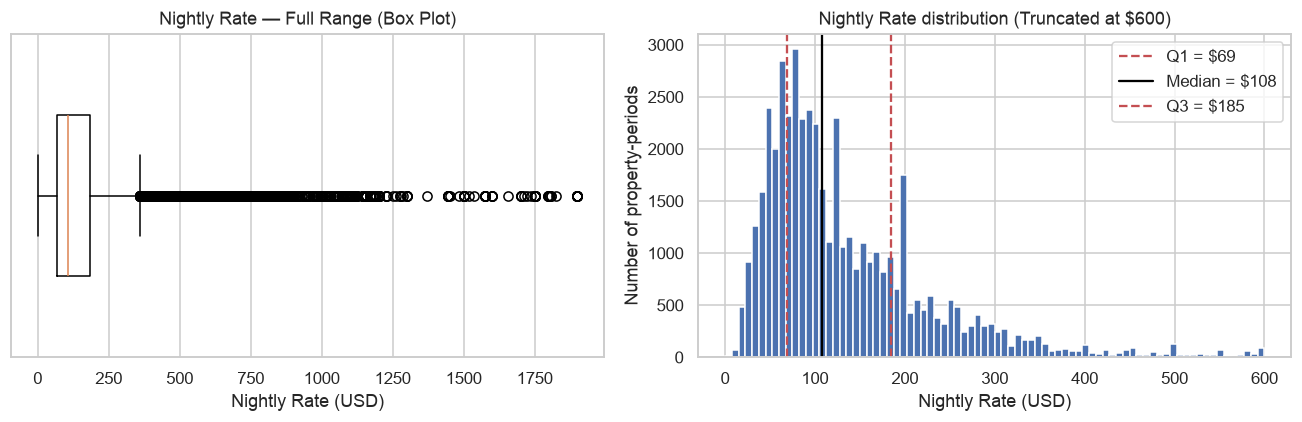

In [2]:
nr = df['Nightly Rate']

# Q1/Q3 are the 25th and 75th percentiles - the two values that bound the middle
# half of the market. The IQR is the width of that band
q1, q3 = nr.quantile(0.25), nr.quantile(0.75)
# Collect every spread statistic into one labelled table
summary = pd.Series({
    'Count (non-null)': nr.notna().sum(),
    'Missing':          nr.isna().sum(),
    'Minimum':          nr.min(),
    'Maximum':          nr.max(),
    'Range (max-min)':  nr.max() - nr.min(),
    'Q1 (25th pct)':    q1,
    'Median (50th pct)': nr.median(),
    'Q3 (75th pct)':    q3,
    'IQR (Q3-Q1)':      q3 - q1,
    'Mean':             nr.mean(),
    'Std deviation':    nr.std(),
})
print('Nightly Rate (USD) — spread statistics')
print('=' * 46)
print(summary.round(2).to_string())
print()
print('Rows used: {} of {} (null Nightly Rate: {})'.format(nr.notna().sum(), len(df), nr.isna().sum()))
print()

# List the most extreme listings so we can judge whether they are real or data errors
cols = ['Airbnb Property ID', 'Neighborhood', 'Listing Type', 'Bedrooms', 'Nightly Rate']
print('5 highest nightly rates')
# nlargest/nsmallest return whole ROWS ranked by one column. Because this is panel
# data these 5 rows can be the same property in 5 different periods, not 5 listings
print(df.nlargest(5, 'Nightly Rate')[cols].to_string(index=False))
print()
print('5 lowest nightly rates')
print(df.nsmallest(5, 'Nightly Rate')[cols].to_string(index=False))
print()

# How much of the market sits inside the IQR box vs out in the tail?
# between() gives True/False per row; .mean() turns that into a percentage
inside = nr.between(q1, q3).mean()
print('Share of listings priced between Q1 (${:.0f}) and Q3 (${:.0f}): {:.1%}'.format(q1, q3, inside))
print('Share priced above $500: {:.2%}   above $1,000: {:.2%}'.format((nr > 500).mean(), (nr > 1000).mean()))
print('99th percentile: ${:.2f}'.format(nr.quantile(0.99)))

# Box plot of the full range to show how far the outliers reach, next to a histogram
# zoomed into the main market to show where listings actually cluster
# The question asks about spread across different LISTINGS, but this is panel data:
# the five highest rows below are one property observed five times. Collapse to one
# median rate per property and confirm the answer is not an artefact of that.
per_listing = df.groupby('Airbnb Property ID')['Nightly Rate'].median()
print()
print('Same statistics at LISTING level (one median rate per property)')
print('  Distinct listings : {:,}  (from {:,} property-period rows)'.format(
    len(per_listing), len(df)))
print('  Range  : ${:,.2f}'.format(per_listing.max() - per_listing.min()))
print('  IQR    : ${:,.2f}   (vs ${:,.2f} at property-period level)'.format(
    per_listing.quantile(0.75) - per_listing.quantile(0.25), q3 - q1))
print('  Median : ${:,.2f}   (vs ${:,.2f})'.format(per_listing.median(), nr.median()))
print('  -> Materially the same answer, so the conclusion is not a panel artefact.')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
try:                                  # matplotlib >= 3.11
    axes[0].boxplot(nr.dropna(), orientation='horizontal', widths=0.5)
except TypeError:                     # older matplotlib, e.g. some Colab images
    axes[0].boxplot(nr.dropna(), vert=False, widths=0.5)
axes[0].set_title('Nightly Rate — Full Range (Box Plot)')
axes[0].set_xlabel('Nightly Rate (USD)')
axes[0].set_yticks([])
# range= cuts the x-axis at $600 so the bars are visible; it hides the long tail,
# which is why the box plot beside it shows the full range instead
axes[1].hist(nr.dropna(), bins=80, range=(0, 600), color='#4C72B0', edgecolor='white')
axes[1].axvline(q1, color='#C44E52', ls='--', label='Q1 = ${:.0f}'.format(q1))
axes[1].axvline(nr.median(), color='black', ls='-', label='Median = ${:.0f}'.format(nr.median()))
axes[1].axvline(q3, color='#C44E52', ls='--', label='Q3 = ${:.0f}'.format(q3))
axes[1].set_title('Nightly Rate distribution (Truncated at $600)') # for readability
axes[1].set_xlabel('Nightly Rate (USD)')
axes[1].set_ylabel('Number of property-periods')
axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 1

Range = $1,899 (min $1, max $1,900). IQR = $116.12 (Q1 $69.00, Q3 $185.12), median $107.50.

The two measures tell very different stories, and the gap between them is the finding: the
range is more than 16 times the IQR. The middle half of the Dallas market is packed into a
narrow $116 band just under $200 a night, while the full range is stretched across nearly $1,900
by a thin tail of luxury listings — only 3.7% of property-periods are priced above $500 and
1.1% above $1,000.

That makes the range a bad way to measure variability here. It is set by exactly two rows and
is dragged up by a single outlier, whereas the IQR describes where listings actually sit. The
mean ($157.17) sitting well above the median ($107.50) confirms the same right skew.

On the extremes. We did not remove them, but they should be read with suspicion. The five
highest rows are all the same property (ID 18054750, a 2-bedroom Central Dallas home) observed
in five different periods at $1,900 — a reminder that this is panel data, so the "top 5 rows"
are not 5 different listings. The $1 minimum is likewise one property (ID 20678468) listed with
0 bedrooms, which looks like a placeholder or data-entry error rather than a real market price.
A single bad row moves the range by hundreds of dollars and the IQR not at all.

**What this means for the business.** Descriptive analysis with a direct **value-capture**
implication. The middle half of Dallas listings competes inside a $116 band, so pricing power for
a typical host lies in small moves within a narrow corridor, not in repositioning into the luxury
tail — only 3.7% of property-periods clear $500. That argues for pricing guidance calibrated in
$10–20 increments rather than broad "premium" positioning, and it means range is the wrong number
to put on a host dashboard: the IQR describes the market a host actually competes in.


---
# Question 2 — Descriptive statistics for `booked_days` and `revenue`

> Provide a summary of key descriptive statistics (mean, median, standard deviation, minimum,
> and maximum) for booked_days and revenue. How do these statistics help you understand the
> overall performance of the properties?

Approach: One table with count, mean, median, std, min and max for both variables. The
mean-to-median ratio is the number to read: if the mean sits well above the median, a minority
of high earners is pulling the average up and the median is the better description of a typical
property.

Because null `booked_days` / `revenue` means "listed but never booked" (see Setup), we print the
table twice — once over booked property-periods only, and once with those rows counted as zero.
The second version is the honest picture of *all* listed inventory.

Null values — booked_days: 16861   revenue: 16861

A. Booked property-periods only (nulls excluded) — n = 31850
------------------------------------------------------------
         booked_days    revenue
Count       31850.00   31850.00
Mean           25.47    3134.13
Median         22.00    2025.00
Std dev        18.77    4249.34
Minimum         1.00      10.00
Maximum       173.00  134209.00

  booked_days  mean/median ratio = 1.16
  revenue      mean/median ratio = 1.55



B. All property-periods, unbooked counted as 0 — n = 48711
----------------------------------------------------------
         booked_days_all  revenue_all
Count           48711.00     48711.00
Mean               16.65      2049.27
Median              9.00       787.00
Std dev            19.42      3745.62
Minimum             0.00         0.00
Maximum           173.00    134209.00

  booked_days_all mean/median ratio = 1.85
  revenue_all  mean/median ratio = 2.60

Percentiles (booked periods only)
          booked_days   revenue
10th pct          4.0    316.00
25th pct         10.0    845.00
50th pct         22.0   2025.00
75th pct         37.0   3919.50
90th pct         51.0   6651.10
99th pct         78.0  20596.74

Share of all revenue earned by the top 10% of property-periods: 38.6%


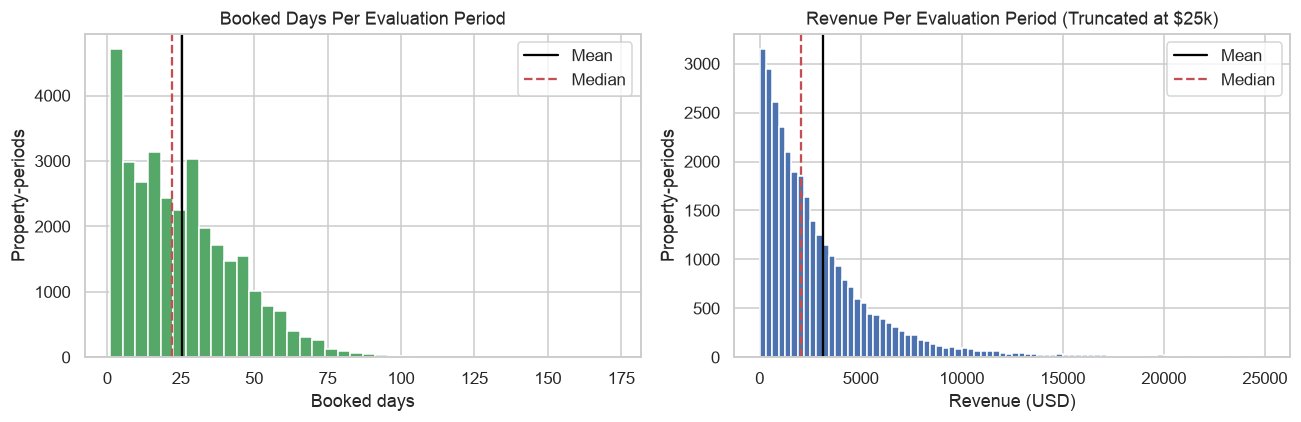

In [3]:
# Builds the same summary table for any set of columns, so we can run it twice:
# once on booked rows only, once with unbooked periods counted as zero
def describe_pair(frame, cols, label):
    # Dict-of-dicts -> DataFrame puts statistics in rows and variables in columns
    out = pd.DataFrame({
        c: {
            'Count':    frame[c].notna().sum(),
            'Mean':     frame[c].mean(),
            'Median':   frame[c].median(),
            'Std dev':  frame[c].std(),
            'Minimum':  frame[c].min(),
            'Maximum':  frame[c].max(),
        } for c in cols
    })
    print(label)
    print('-' * len(label))
    print(out.round(2).to_string())
    print()
    for col in cols:
        m, md_ = frame[col].mean(), frame[col].median()
        print('  {:<12} mean/median ratio = {:.2f}'.format(col, m / md_))
    print()
    return out

# How many property-periods have no booking data at all
print('Null values — booked_days: {}   revenue: {}'.format(
    df['booked_days'].isna().sum(), df['revenue'].isna().sum()))
print()

# Table A = booked periods only. Table B = the same stats with unbooked periods
# counted as zero, which is the honest view of all listed inventory
a = describe_pair(df, ['booked_days', 'revenue'],
                  'A. Booked property-periods only (nulls excluded) — n = {}'.format(
                      df['booked_days'].notna().sum()))
b = describe_pair(df.rename(columns={'booked_days_z': 'booked_days_all', 'revenue_z': 'revenue_all'}),
                  ['booked_days_all', 'revenue_all'],
                  'B. All property-periods, unbooked counted as 0 — n = {}'.format(len(df)))

# Percentiles give a fuller sense of the spread than min/max alone
pct = df[['booked_days', 'revenue']].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(2)
pct.index = ['10th pct', '25th pct', '50th pct', '75th pct', '90th pct', '99th pct']
print('Percentiles (booked periods only)')
print(pct.to_string())
print()
# Revenue earned by the top 10% of rows, divided by revenue earned by everyone
# A high number means earnings are concentrated in a few listings
top10_share = df.nlargest(int(0.10 * df['revenue'].notna().sum()), 'revenue')['revenue'].sum() / df['revenue'].sum()
print('Share of all revenue earned by the top 10% of property-periods: {:.1%}'.format(top10_share))

# Histograms of booked_days and revenue to show the shape behind those averages,
# with mean and median marked so the skew is visible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['booked_days'].dropna(), bins=40, color='#55A868', edgecolor='white')
axes[0].axvline(df['booked_days'].mean(), color='black', ls='-', label='Mean')
axes[0].axvline(df['booked_days'].median(), color='#C44E52', ls='--', label='Median')
axes[0].set_title('Booked Days Per Evaluation Period')
axes[0].set_xlabel('Booked days'); axes[0].set_ylabel('Property-periods'); axes[0].legend()
axes[1].hist(df['revenue'].dropna(), bins=80, range=(0, 25000), color='#4C72B0', edgecolor='white')
axes[1].axvline(df['revenue'].mean(), color='black', ls='-', label='Mean')
axes[1].axvline(df['revenue'].median(), color='#C44E52', ls='--', label='Median')
axes[1].set_title('Revenue Per Evaluation Period (Truncated at $25k)') # for readability
axes[1].set_xlabel('Revenue (USD)'); axes[1].set_ylabel('Property-periods'); axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 2

The question asks how these statistics describe "the overall performance of the properties", so
the full listed population leads and the booked-only subset follows. They answer different
questions, and the distance between them is itself the finding.

**All listed property-periods (n = 48,711), idle periods counted as zero:**

| | booked_days | revenue |
|---|---|---|
| Mean | 16.65 | $2,049.27 |
| Median | 9.00 | $787.00 |
| Std dev | 19.42 | $3,745.62 |
| Min | 0.00 | $0.00 |
| Max | 173.00 | $134,209.00 |

**On-market property-periods only (n = 41,400)** — excluding 7,311 rows with no
`available_days` either, which are most likely off-market rather than idle:

| | booked_days | revenue |
|---|---|---|
| Median | 13.00 | $1,261 |
| Share earning nothing | 23.1% | 23.1% |

**Booked property-periods only (n = 31,850):**

| | booked_days | revenue |
|---|---|---|
| Mean | 25.47 | $3,134.13 |
| Median | 22.00 | $2,025.00 |
| Std dev | 18.77 | $4,249.34 |
| Min | 1.00 | $10.00 |
| Max | 173.00 | $134,209.00 |

What these say about performance: The typical booked property earns about $2,025 per
evaluation period on 22 booked days. The mean/median ratios separate the two variables
cleanly: `booked_days` is only mildly skewed (ratio 1.16), because it is physically capped
by the length of the period, and its max of 173 days is a real ceiling. Revenue doesn't really have a cap,
and its ratio of 1.55 — plus a standard deviation ($4,249) larger than its own mean —
shows a small group of very high earners pulling the average up. The top 10% of
*booked* property-periods take 38.6% of the revenue they earn. Quoting the $3,134 mean as "typical" would
overstate what a normal host makes by more than 50%.

Why the two tables differ, and why it matters. 16,861
property-periods (34.6%) have no booked days at all. Counting those as zero, which is the
honest view of all listed inventory, the picture changes sharply: median revenue falls from
$2,025 to $787 and median booked days from 22 to 9. So roughly a third of Dallas
inventory earns nothing — though that figure depends on what counts as inventory. 7,311 of
those 16,861 rows have no `available_days` recorded either, so they were probably off the
market entirely rather than listed and unbooked. Restricting to rows we can confirm were
on the market, the idle share is **23.1%** and median revenue is **$1,261**. The direction is
unchanged on either reading; any performance claim simply needs to state which population it
describes.

**What this means for the business.** Descriptive, and the finding that matters is operational
rather than statistical: **34.6% of listed inventory earns nothing in a given period.** That is an
**operational excellence** problem — utilisation of supply Airbnb already has — and it is far
cheaper to address than acquiring new listings. A booked property returns a median $2,025 per
period; the same property idle returns $0. Converting even a slice of that idle third is the
largest single pool of unrealised revenue in the dataset.


---
# Question 3 — Booking patterns: Superhosts vs non-Superhosts

> What can you infer about booking patterns for Superhosts compared to non-Superhosts?
> Determine the best way to visualize the booked_days data and explain your findings.

Chart choice and why: 
Side-by-side box plots, with overlapping density curves as a second view. A bar chart of two means would hide the spread, and spread is the whole point of a booking-pattern comparison — box plots show median, IQR and outliers for both groups at once, and the density curves show whether the two distributions have different *shapes* or just different centres.

Watch for: The groups are very different sizes, so we print group counts alongside and
compare medians as well as means.

Rows used: 31850 of 48711 (16861 dropped for null booked_days)



booked_days by Superhost status
                  Count   Mean  Median  Std dev    Q1    Q3    Max   IQR
Superhost status                                                        
Non-Superhost     18987  23.67    20.0    18.67   8.0  35.0  173.0  27.0
Superhost         12863  28.12    26.0    18.62  13.0  40.0  133.0  27.0

Difference in means  (Superhost - Non): +4.46 days
Difference in medians (Superhost - Non): +6.00 days
Superhost median is 1.3x the non-Superhost median

Share of property-periods with NO bookings at all:
Superhost status
Non-Superhost    42.1%
Superhost        19.2%


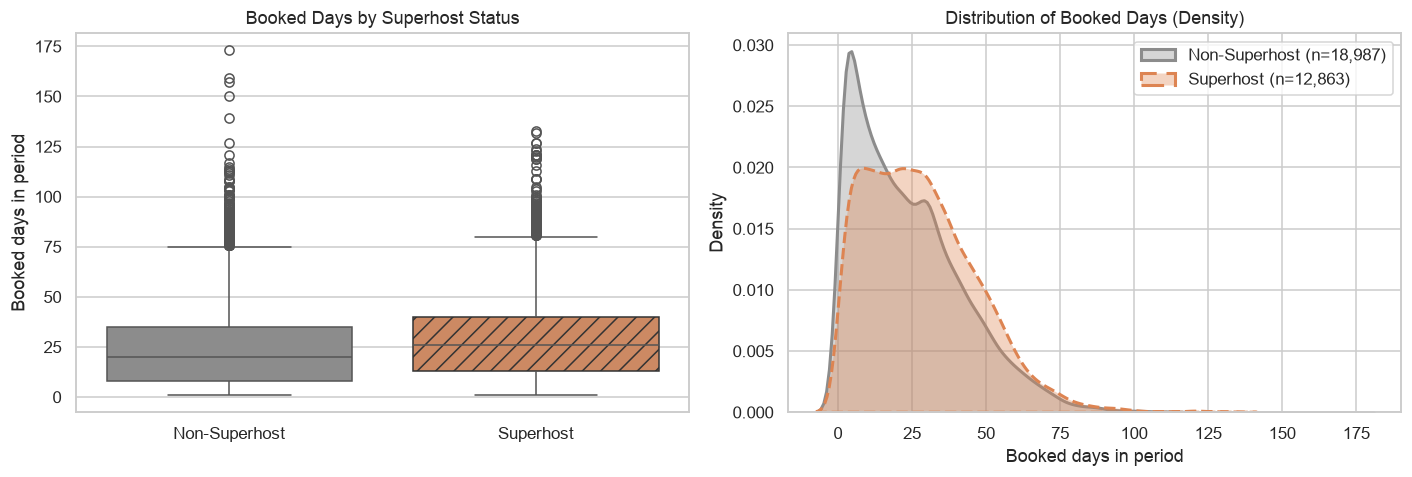

In [4]:
# Keep only rows that actually have booking data. subset= means 'judge missingness
# on this column only', not on the whole row
bd = df.dropna(subset=['booked_days'])
print('Rows used: {} of {} ({} dropped for null booked_days)'.format(
    len(bd), len(df), df['booked_days'].isna().sum()))
print()

# A groupby object: the same calculation gets applied once per group
grp = bd.groupby('Superhost status')['booked_days']
tbl = pd.DataFrame({
    'Count':  grp.count(),
    'Mean':   grp.mean(),
    'Median': grp.median(),
    'Std dev': grp.std(),
    'Q1':     grp.quantile(0.25),
    'Q3':     grp.quantile(0.75),
    'Max':    grp.max(),
})
tbl['IQR'] = tbl['Q3'] - tbl['Q1']
print('booked_days by Superhost status')
print(tbl.round(2).to_string())
print()

# Split into the two groups so we can difference them directly
sh = bd.loc[bd['Superhost'] == 1, 'booked_days']
non = bd.loc[bd['Superhost'] == 0, 'booked_days']
print('Difference in means  (Superhost - Non): {:+.2f} days'.format(sh.mean() - non.mean()))
print('Difference in medians (Superhost - Non): {:+.2f} days'.format(sh.median() - non.median()))
print('Superhost median is {:.1f}x the non-Superhost median'.format(sh.median() / non.median()))
print()

# Unbooked periods are excluded above; that itself differs by group, so report it
print('Share of property-periods with NO bookings at all:')
# Share of each group's rows that are missing - i.e. periods with zero bookings
# This runs on the FULL df, not bd, because bd has already dropped those rows
print((df.groupby('Superhost status')['booked_days'].apply(lambda s: s.isna().mean())
         .mul(100).round(1).astype(str) + '%').to_string())

# Box plot of booked days by group to compare medians, spread and outliers,
# plus density curves to show whether the two distributions differ in shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=bd, x='Superhost status', y='booked_days',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
hatch_second(axes[0])            # greyscale safety, see setup cell
axes[0].set_title('Booked Days by Superhost Status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Booked days in period')

# Distinct linestyle as well as colour, so the two curves stay separable in print
for lab, colr, ls in [('Non-Superhost', '#8C8C8C', '-'), ('Superhost', '#DD8452', '--')]:
    sns.kdeplot(bd.loc[bd['Superhost status'] == lab, 'booked_days'],
                label='{} (n={:,})'.format(lab, int((bd['Superhost status'] == lab).sum())),
                fill=True, alpha=0.35, color=colr, linestyle=ls,
                linewidth=2, ax=axes[1])
axes[1].set_title('Distribution of Booked Days (Density)')
axes[1].set_xlabel('Booked days in period'); axes[1].set_ylabel('Density')
axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 3

Why box plots? A bar chart of two means would report a 4.5-day gap and hide the fact that both distributions are wide and heavily overlapping. Box plots show median, IQR and outliers for both groups at once; the density curves beside them show whether the shapes differ or only the centers.

| | n | Mean | Median | Q1 | Q3 | IQR |
|---|---|---|---|---|---|---|
| Non-Superhost | 18,987 | 23.67 | 20.0 | 8.0 | 35.0 | 27.0 |
| Superhost | 12,863 | 28.12 | 26.0 | 13.0 | 40.0 | 27.0 |

Superhosts book +4.46 days more on the mean and +6.0 days more on the median — the median
gap is the larger of the two, so this is not a handful of outliers dragging an average. What the box plots add is that the IQR is identical at 27 days for both groups: the Superhost
distribution is not tighter or more consistent, it is the same shape shifted upward by about a week of bookings per period. Superhost listings are not a different kind of business, just a better-booked version of the same one.

One caveat before reading anything causal into this. These are self-selected groups, and Airbnb
awards the badge partly on booking and review activity — so "Superhosts sit idle less" and
"listings that sit idle less become Superhosts" are the same table read two ways. Question 7
tests the direction directly and finds no revenue effect from the badge itself.

The largest difference is one the box plots cannot show, because it lives in the rows we had
to drop. Among non-Superhosts, 42.1% of property-periods had no bookings at all; among
Superhosts, only 19.2%. Restricting to rows we can confirm were on the market (excluding the
7,311 with no `available_days`), the same gap holds at **28.0% against 14.5%**. So the real booking-pattern gap is not mainly that a booked
Superhost books more nights — it is that a Superhost listing is less than half as likely to
sit empty for an entire period. Any comparison restricted to booked rows understates the
advantage by a wide margin.

**What this means for the business.** The +6-day median gap is a **customer intimacy** story:
responsive, well-reviewed hosts get booked more. But the **operational excellence** finding is the
bigger one — a non-Superhost listing sits completely idle in 42.1% of periods against 19.2% for
Superhosts. Airbnb captures value per booked night, so idle inventory is lost revenue on both
sides of the marketplace. Whatever distinguishes these listings more than halves the idle rate, and
identifying it is worth more than the extra week of bookings among already-booked listings.


---
# Question 4 — Seasonal patterns in booking days for Superhosts

> Are there any seasonal patterns in the booking days for Superhosts? Select the best approach
> to visualize the trend in booked_days over different periods and discuss the patterns you
> identify.

Chart choice and why: A line chart of mean `booked_days` by calendar month, restricted to
Superhosts. "Seasonal" means calendar months, so this is the first question that uses
`Scraped Date` rather than the period number. We add the non-Superhost line even though the
question doesn't ask for it: if both lines share the same shape, the pattern is the Dallas
market, not something about Superhosts.

Watch for: We check how many years and which months are actually present before averaging
months across years — the scrape is quarterly, so not every calendar month is covered.

Date range: 2016-08-01 to 2020-06-22
Distinct years  : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Distinct months present: [np.int32(2), np.int32(3), np.int32(5), np.int32(6), np.int32(8), np.int32(9), np.int32(11), np.int32(12)]
NOTE: scrapes are quarterly, so only 8 of 12 calendar months appear. Months with no
      scrape are absent from the chart, not zero.



Mean booked_days by calendar month (all months present in the data)
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                       24.77      27.86
Mar                       21.27      17.42
May                       22.74      30.12
Jun                       13.35      21.25
Aug                       26.72      29.64
Sep                       17.94      19.00
Nov                       20.85      25.11
Dec                       17.86      21.62

Rows behind each month
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                        4561       3329
Mar                          33         12
May                        4859       3220
Jun                          88         56
Aug                        4644       3066
Sep                          35          7
Nov                        4738       3165
Dec                          29          8

Well-sampled months (>=500 rows in BOTH groups)

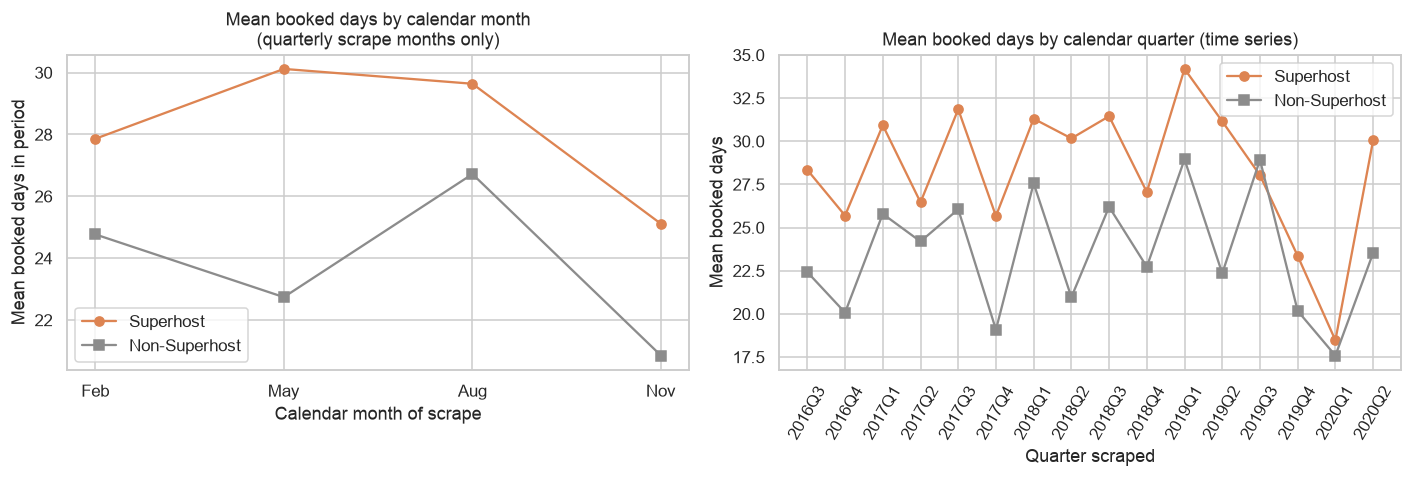


Mean booked_days by quarter (time series above)
Superhost status  Non-Superhost  Superhost
Scraped Date                              
2016Q3                    22.42      28.34
2016Q4                    20.07      25.69
2017Q1                    25.79      30.93
2017Q2                    24.19      26.46
2017Q3                    26.06      31.85
2017Q4                    19.09      25.67
2018Q1                    27.56      31.31
2018Q2                    20.97      30.17
2018Q3                    26.20      31.45
2018Q4                    22.73      27.06
2019Q1                    28.95      34.19
2019Q2                    22.35      31.15
2019Q3                    28.93      28.03
2019Q4                    20.17      23.36
2020Q1                    17.58      18.47
2020Q2                    23.52      30.05


In [5]:
# Q4: seasonality. This needs real calendar dates, so parse the date column first
df['Scraped Date'] = pd.to_datetime(df['Scraped Date'])
print('Date range: {} to {}'.format(df['Scraped Date'].min().date(), df['Scraped Date'].max().date()))
print('Distinct years  :', sorted(df['Scraped Date'].dt.year.unique()))
print('Distinct months present:', sorted(df['Scraped Date'].dt.month.unique()))
print('NOTE: scrapes are quarterly, so only {} of 12 calendar months appear. Months with no'
      .format(df['Scraped Date'].dt.month.nunique()))
print('      scrape are absent from the chart, not zero.')
print()

# Pull calendar month and year out of the date for grouping
# Added together rather than one at a time; separate inserts fragment the frame and
# emit a PerformanceWarning that would print into the graded PDF.
df = pd.concat([df, pd.DataFrame({
    'Month': df['Scraped Date'].dt.month,
    'Year': df['Scraped Date'].dt.year,
}, index=df.index)], axis=1)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

bd = df.dropna(subset=['booked_days'])
# Mean, median and row count of booked days for each month/group combination
monthly = (bd.groupby(['Month', 'Superhost status'])['booked_days']
             .agg(['mean', 'median', 'count']).round(2).reset_index())
# pivot reshapes long -> wide: one row per month, one column per group
piv_mean = monthly.pivot(index='Month', columns='Superhost status', values='mean')
piv_n = monthly.pivot(index='Month', columns='Superhost status', values='count')

print('Mean booked_days by calendar month (all months present in the data)')
print(piv_mean.rename(index=month_names).round(2).to_string())
print()
print('Rows behind each month')
print(piv_n.rename(index=month_names).astype(int).to_string())
print()

# Four months hold only a handful of straggler scrapes. Averaging 12 rows next to 3,300
# would invent a seasonal swing that is really sampling noise, so we read the pattern off
# the well-sampled months only and say which those are
# .all(axis=1) demands the threshold is met in BOTH columns, so a month only counts
# as well-sampled if both groups have enough rows
well = piv_n[(piv_n >= 500).all(axis=1)].index.tolist()
thin = [m for m in piv_n.index if m not in well]
print('Well-sampled months (>=500 rows in BOTH groups):', [month_names[m] for m in well])
print('Thin months excluded from the chart          :',
      ['{} (n={})'.format(month_names[m], int(piv_n.loc[m].sum())) for m in thin])
print()

# Peak and trough months, read off the well-sampled months only
pm = piv_mean.loc[well]
sh_m = pm['Superhost']
print('Superhost peak month : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmax()], sh_m.max()))
print('Superhost low month  : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmin()], sh_m.min()))
print('Peak-to-trough swing : {:.1f} days ({:.0%} above the low month)'.format(
    sh_m.max() - sh_m.min(), (sh_m.max() - sh_m.min()) / sh_m.min()))
non_m = pm['Non-Superhost']
print('Non-Superhost peak   : {}   low: {}   swing: {:.1f} days'.format(
    month_names[non_m.idxmax()], month_names[non_m.idxmin()], non_m.max() - non_m.min()))
# Vertical gap between the two lines on the chart: how many more days a Superhost
# listing books than a non-Superhost one, in each month
print()
lead = (pm['Superhost'] - pm['Non-Superhost']).rename(index=month_names).round(2)
lead.index.name = None          # drop the stray 'Month' header pandas prints
print('Superhost lead in mean booked days (Superhost - Non-Superhost), by month:')
print(lead.to_string())

# Left: line chart of booked days by calendar month to show the seasonal cycle
# Right: the same measure by quarter over time, to separate cycle from trend
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[0].plot(range(len(well)), pm[lab], marker=mk, color=colr, label=lab)
axes[0].set_xticks(range(len(well)))
axes[0].set_xticklabels([month_names[m] for m in well])
axes[0].set_title('Mean booked days by calendar month\n(quarterly scrape months only)')
axes[0].set_xlabel('Calendar month of scrape')
axes[0].set_ylabel('Mean booked days in period')
axes[0].legend(title='')

# Second view: the actual time series, so a repeating cycle can be told apart from a trend
# .dt.to_period('Q') buckets each date into its calendar quarter (e.g. 2019Q2)
# .unstack() then moves the Superhost labels up into columns
ts = (bd.groupby([bd['Scraped Date'].dt.to_period('Q'), 'Superhost status'])['booked_days']
        .mean().unstack())
ts.index = ts.index.astype(str)
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[1].plot(ts.index, ts[lab], marker=mk, color=colr, label=lab)
axes[1].set_title('Mean booked days by calendar quarter (time series)')
axes[1].set_xlabel('Quarter scraped'); axes[1].set_ylabel('Mean booked days')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend(title='')
plt.tight_layout()
plt.show()

print()
print('Mean booked_days by quarter (time series above)')
print(ts.round(2).to_string())

### Findings — Question 4

A sampling caveat first, because it changes the answer. The data is scraped quarterly,
so only 8 of 12 calendar months appear at all, and 4 of those (Mar, Jun, Sep, Dec) hold just a
few dozen straggler rows against 3,000+ in the real scrape months. Reading a "March trough" off
12 Superhost rows would be inventing a season out of sampling noise. We therefore read the
pattern off the four well-sampled months — February, May, August, November — and exclude the
rest from the chart.

Mean booked days for Superhosts: Feb 27.9 · May 30.1 · Aug 29.6 · Nov 25.1.

The pattern: There is a clear and modest season. Superhost bookings peak in May (30.1
days), hold nearly as high through August (29.6), and fall to a low in November (25.1) —
a 5.0-day swing, about 20% between the best and worst month. Spring and summer are the
Dallas booking season; late autumn is the trough.

The season is the market, not the badge. Non-Superhosts follow the same shape (peak Aug
26.7, trough Nov 20.9), which tells us this is Dallas demand rather than anything Superhosts do.
What is specific to Superhosts is that their line sits above the non-Superhost line in every
month, by 2.9 to 7.4 days, and the gap is widest in the peak month of May. Superhosts capture
disproportionately more of the seasonal upside.

The quarterly time series adds a caution about reading months across years. It shows the
seasonal cycle repeating on top of a mild upward drift from 2016 to 2019, then a visible dip in
2020 Q1 (Superhost mean 18.5 booked days, the lowest point in the series) as COVID hit. Since
the monthly averages pool five years together, that shock is silently mixed into the Feb figure.

**What this means for the business.** Descriptive shading into **predictive**: a 5.0-day swing
between May and November is a forecastable, market-wide pattern, so it belongs in capacity and
pricing planning and should not be read as host performance. Because the seasonal shape is
identical for both groups, it is Dallas demand rather than the badge. The actionable detail is
that the Superhost premium is *widest* in the peak month — Superhosts capture disproportionate
upside exactly when demand is highest, which is a **value-capture** argument for putting dynamic
pricing support in front of non-Superhosts ahead of the spring season.


---
# Question 5 — Superhost status and number of reviews

> How does Superhost status impact the number of reviews a property receives? Choose an
> appropriate method to compare the numReviews_pastYear for Superhosts and non-Superhosts.

Method choice and why: Group summary statistics plus box plots, backed by two significance
tests. Review counts are right-skewed and the two groups differ in size and variance, so we use
Welch's t-test (does not assume equal variances) for the means and Mann-Whitney U as a
non-parametric check that does not assume normality. If both agree, the gap is not sampling
noise.

Important caveat for the written answer: This is correlational, and the direction is
ambiguous: Superhost status is awarded partly on the basis of review activity, so we cannot
claim the badge causes reviews. It is at least as likely that reviews cause the badge.

Rows used: 37492 of 48711 (11219 dropped for null numReviews_pastYear)

numReviews_pastYear by Superhost status
                  Count    Mean  Median  Std dev    Q1     Q3     Max
Superhost status                                                     
Non-Superhost     22546  240.49    27.0   601.66   5.0  184.0  3305.0
Superhost         14946  138.78    46.0   288.59  20.0  131.0  3133.0

Difference in means  : -101.71 reviews  (Superhost 138.8 vs 240.5)
Difference in medians: +19.0 reviews  (Superhost 46 vs 27)
Superhost mean is 0.58x the non-Superhost mean

Welch's t-test (unequal variances)
  t-statistic = -21.870
  p-value     = 2.614e-105  (< 0.001)
Mann-Whitney U (non-parametric check)
  U-statistic = 199,394,438
  p-value     = 2.198e-199  (< 0.001)

Cohen's d (effect size) = -0.203
  For scale: 0.2 small, 0.5 medium, 0.8 large.


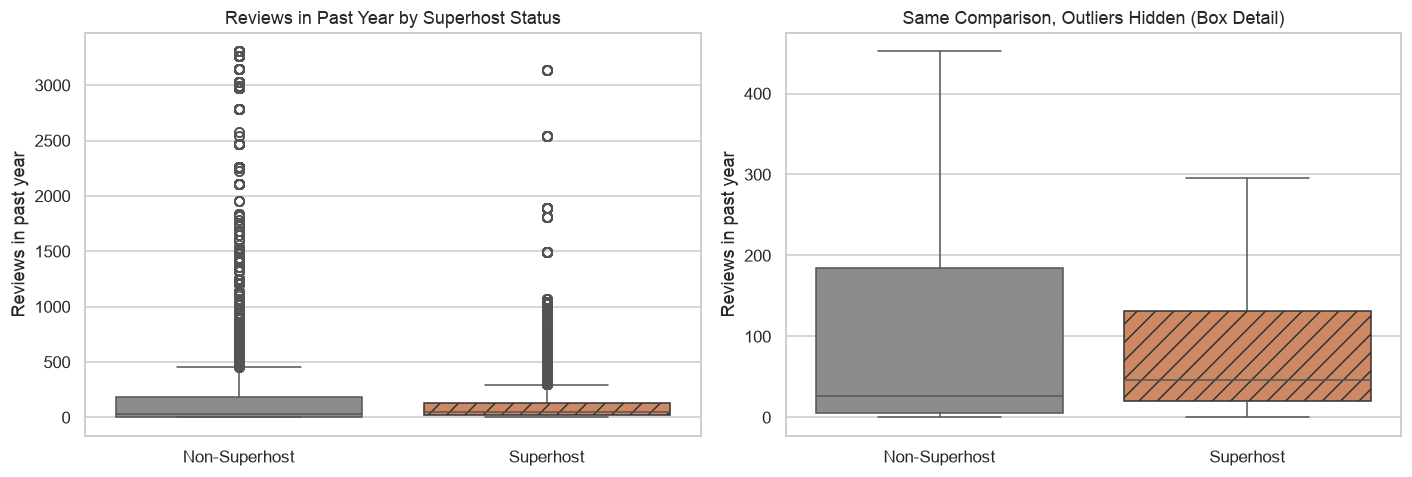

In [6]:
rv = df.dropna(subset=['numReviews_pastYear'])
print('Rows used: {} of {} ({} dropped for null numReviews_pastYear)'.format(
    len(rv), len(df), df['numReviews_pastYear'].isna().sum()))
print()

# Summary table of review counts for each group
grp = rv.groupby('Superhost status')['numReviews_pastYear']
tbl = pd.DataFrame({'Count': grp.count(), 'Mean': grp.mean(), 'Median': grp.median(),
                    'Std dev': grp.std(), 'Q1': grp.quantile(0.25), 'Q3': grp.quantile(0.75),
                    'Max': grp.max()})
print('numReviews_pastYear by Superhost status')
print(tbl.round(2).to_string())
print()

# Split the two groups so they can be compared and tested
sh = rv.loc[rv['Superhost'] == 1, 'numReviews_pastYear']
non = rv.loc[rv['Superhost'] == 0, 'numReviews_pastYear']
print('Difference in means  : {:+.2f} reviews  (Superhost {:.1f} vs {:.1f})'.format(
    sh.mean() - non.mean(), sh.mean(), non.mean()))
print('Difference in medians: {:+.1f} reviews  (Superhost {:.0f} vs {:.0f})'.format(
    sh.median() - non.median(), sh.median(), non.median()))
print('Superhost mean is {:.2f}x the non-Superhost mean'.format(sh.mean() / non.mean()))
print()

# equal_var=False makes this Welch's t-test, which does not assume the two groups
# have the same variance or size - both are true here
t, p = stats.ttest_ind(sh, non, equal_var=False)
print("Welch's t-test (unequal variances)")
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Compares ranks rather than means, so a few huge values cannot distort it
u, pu = stats.mannwhitneyu(sh, non, alternative='two-sided')
print('Mann-Whitney U (non-parametric check)')
print('  U-statistic = {:,.0f}'.format(u))
print('  p-value     = {:.3e}{}'.format(pu, '  (< 0.001)' if pu < 0.001 else ''))
# Effect size: a significant p-value on 37k rows says little on its own
# Cohen's d = gap between means measured in standard deviations. On 37k rows almost
# any gap is 'significant', so this says whether it is actually BIG
pooled = np.sqrt(((len(sh)-1)*sh.var() + (len(non)-1)*non.var()) / (len(sh)+len(non)-2))
print("\nCohen's d (effect size) = {:.3f}".format((sh.mean() - non.mean()) / pooled))
print('  For scale: 0.2 small, 0.5 medium, 0.8 large.')

# Box plots of reviews by group. The second hides outliers so the boxes themselves
# are readable - the tail is so long it flattens the first chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
hatch_second(axes[0])            # greyscale safety, see setup cell
axes[0].set_title('Reviews in Past Year by Superhost Status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Reviews in past year')

sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=axes[1])
hatch_second(axes[1])            # greyscale safety, see setup cell
axes[1].set_title('Same Comparison, Outliers Hidden (Box Detail)')
axes[1].set_xlabel(''); axes[1].set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Q5 follow-up — the mean and the median disagree, so we check why

The table above shows something odd: Superhosts have a higher median review count but a
lower mean. When those two point in opposite directions, a skewed tail is driving the mean,
and we should find out what is in that tail before writing an answer.

Our hypothesis: `numReviews_pastYear` scales with how many listings a host operates, so large
commercial operators sit in the tail — and those operators are concentrated among
non-Superhosts. We test it by counting listings per host and re-running the comparison on
single-listing hosts only, which removes the confound.

Mean reviews by size of host portfolio (distinct listings operated)
           count   mean  median
n_props                        
1 listing  10569   19.8     9.0
2           4858   35.2    18.0
3-5         5635   55.0    28.0
6-20        6438  260.2   110.0
21+         9992  513.5   188.0

-> Review counts rise steeply with portfolio size, so this column reflects the HOST,
   not just the property.

Portfolio size by Superhost status
                   mean  median
Superhost status               
Non-Superhost     72.79     5.0
Superhost         39.54     3.0

-> The average non-Superhost ROW belongs to a host with a far larger portfolio, which
   is what pulls their MEAN review count up. This is a row-weighting effect: a large
   operator contributes one row per listing per period. At HOST level the median host
   in either group runs a single listing.

Like-for-like comparison: single-listing hosts only (n = 10569)
                  count   mean  median    std
Superhost status     

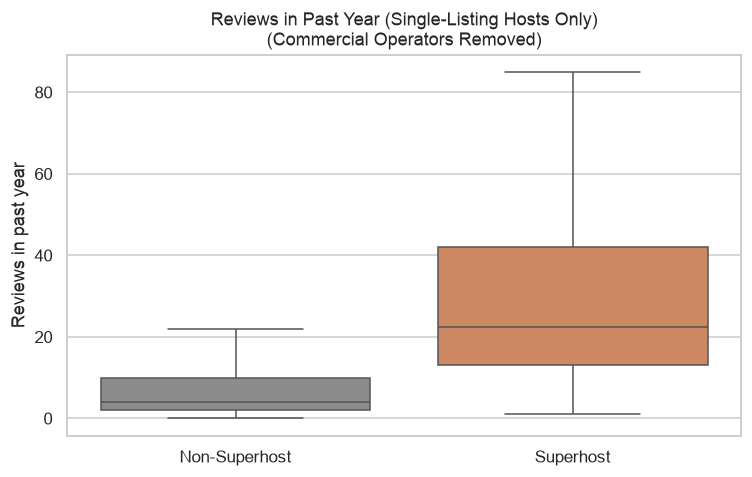

In [7]:
# How many distinct properties does each host operate?
# nunique() counts DISTINCT properties per host, so a host appearing in many periods
# is still counted once per property
props_per_host = rv.groupby('Airbnb Host ID')['Airbnb Property ID'].nunique().rename('n_props')
# join(..., on=) attaches that host-level count back onto every row of that host
rv2 = rv.join(props_per_host, on='Airbnb Host ID')

# Does review count track how many listings a host runs?
print('Mean reviews by size of host portfolio (distinct listings operated)')
# pd.cut sorts a numeric column into labelled bands. Edges are (0,1], (1,2] ... so
# '1 listing' means exactly one
bands = pd.cut(rv2['n_props'], [0, 1, 2, 5, 20, 10000],
               labels=['1 listing', '2', '3-5', '6-20', '21+'])
print(rv2.groupby(bands, observed=True)['numReviews_pastYear']
         .agg(['count', 'mean', 'median']).round(1).to_string())
print()
print('-> Review counts rise steeply with portfolio size, so this column reflects the HOST,')
print('   not just the property.')
print()
# Compare typical portfolio size between the two groups
print('Portfolio size by Superhost status')
print(rv2.groupby('Superhost status')['n_props'].agg(['mean', 'median']).round(2).to_string())
print()
print('-> The average non-Superhost ROW belongs to a host with a far larger portfolio, which')
print('   is what pulls their MEAN review count up. This is a row-weighting effect: a large')
print('   operator contributes one row per listing per period. At HOST level the median host')
print('   in either group runs a single listing.')
print()

# Re-run the comparison with the confound removed
# Hosts with exactly one listing: removes commercial operators, which is the
# confound that made the mean and median disagree above
single = rv2[rv2['n_props'] == 1]
print('=' * 62)
print('Like-for-like comparison: single-listing hosts only (n = {})'.format(len(single)))
print('=' * 62)
print(single.groupby('Superhost status')['numReviews_pastYear']
            .agg(['count', 'mean', 'median', 'std']).round(2).to_string())
print()
a = single.loc[single['Superhost'] == 1, 'numReviews_pastYear']
b = single.loc[single['Superhost'] == 0, 'numReviews_pastYear']
print('Superhost mean is {:.2f}x the non-Superhost mean   ({:.1f} vs {:.1f})'.format(
    a.mean() / b.mean(), a.mean(), b.mean()))
print('Superhost median is {:.2f}x the non-Superhost median ({:.1f} vs {:.1f})'.format(
    a.median() / b.median(), a.median(), b.median()))
print("Welch's t-test p-value : {:.3e}".format(stats.ttest_ind(a, b, equal_var=False)[1]))
print('Mann-Whitney U p-value : {:.3e}'.format(stats.mannwhitneyu(a, b, alternative='two-sided')[1]))

# Box plot of reviews for single-listing hosts only - the like-for-like comparison,
# with commercial operators removed
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=single, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=ax)
ax.set_title('Reviews in Past Year (Single-Listing Hosts Only)\n(Commercial Operators Removed)')
ax.set_xlabel(''); ax.set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Findings — Question 5

The headline comparison contradicts itself, and that is the interesting part. Across all
37,492 rows with review data, Superhosts have a higher median (46 vs 27 reviews) but a
lower mean (138.8 vs 240.5). Both tests are significant (Welch p ≈ 3e-105, Mann-Whitney
p ≈ 2e-199), but they are significant in opposite directions, so significance is not the issue
— on 37,000 rows almost anything reaches significance, which is why we also report Cohen's d
(-0.20, small). A p-value cannot tell us which of two contradictory answers is right.

What is in the tail. `numReviews_pastYear` rises steeply with the size of the host's
portfolio — from a mean of 19.8 reviews for single-listing hosts to 513.5 for hosts with 21+
listings. The column reflects the host, not the individual property. And the average non-Superhost *row*
belongs to a host operating 72.8 listings, against 39.5 for Superhost rows — a large operator
contributes one row per listing per period, so a handful of them dominate the non-Superhost
mean. (At host level the comparison reverses and the median host in either group runs a single
listing; it is the row weighting, not the hosts, that creates the confound.) So the non-Superhost mean
is inflated by large commercial operators, who accumulate enormous review counts and are
under-represented among Superhosts (21.7% of rows from hosts with 21+ listings carry the badge,
against 32.7% of rows overall).

The like-for-like answer. Restricting to hosts with exactly one listing (n = 10,569) removes
the confound, and the contradiction disappears — both statistics now point the same way:

| Single-listing hosts | n | Mean | Median |
|---|---|---|---|
| Non-Superhost | 6,547 | 12.5 | 4.0 |
| Superhost | 4,022 | 31.7 | 22.5 |

Superhosts receive 2.5x the mean and 5.6x the median number of reviews (both p < 0.001).
That is the finding: Superhost status is associated with substantially more reviews, and the
raw comparison hid it entirely behind a composition effect.

Causation caveat: This is correlational, and the direction is genuinely ambiguous — Airbnb
awards Superhost status partly on the basis of review activity, so it is at least as plausible
that reviews cause the badge as the reverse. We cannot separate the two with this data.

**What this means for the business.** Once the portfolio-size confound is removed,
single-listing Superhosts receive 5.6x the median reviews of comparable non-Superhosts. Reviews
are the trust signal the marketplace runs on, so this is **customer intimacy** feeding
**value-chain coordination**: more reviews reduce buyer uncertainty and make matching cheaper for
Airbnb. The caution for any decision built on this is that the causal direction is genuinely
ambiguous — the badge is awarded partly *on* review activity — so neither Airbnb nor a host can
treat "earn the badge" as a route to more reviews.


---
# Question 6 — Histogram of revenue by Superhost status

> Use a histogram to visualize the distribution of revenue for listings. How does the
> distribution differ between properties with Superhost status and those without?

Approach: Revenue is heavily right-skewed, and a plain histogram is one tall bar near zero and a flat invisible tail. We show two versions on shared bins: the raw scale, and a log-scaled x-axis where the shape of both distributions is actually readable. We read the answer off the log version and say so.

Decision stated explicitly: property-periods with no bookings (null revenue) are excluded
from the histograms, because a log axis cannot show zero. Their counts are printed below so the
exclusion is visible.

Rows used: 31850 of 48711 (16861 excluded — no bookings in the period)

revenue by Superhost status
                           Non-Superhost  Superhost
Count                           18987.00   12863.00
Mean                             2938.92    3422.28
Median                           1868.00    2229.00
Std dev                          3862.47    4748.83
Skewness                            4.83       7.24
Max                             77500.00  134209.00
Rows with revenue == 0              0.00       0.00
Unbooked periods excluded       13804.00    3057.00

Both groups are strongly right-skewed (skew >> 0), so the median describes a typical
property far better than the mean does.

Median revenue: Superhost $2,229 vs Non-Superhost $1,868  (+19%)
Mean revenue  : Superhost $3,422 vs Non-Superhost $2,939  (+16%)


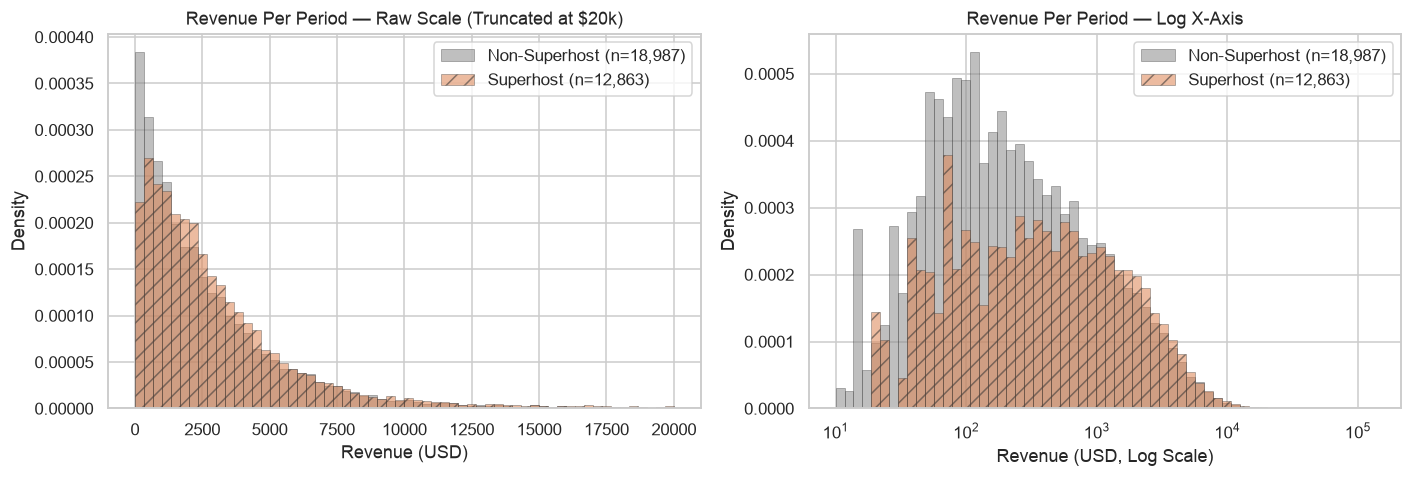

In [8]:
rev = df.dropna(subset=['revenue'])
print('Rows used: {} of {} ({} excluded — no bookings in the period)'.format(
    len(rev), len(df), df['revenue'].isna().sum()))
print()

# Per-group revenue statistics, including skewness to quantify the right tail
stats_tbl = pd.DataFrame({
    lab: {
        'Count':            g['revenue'].count(),
        'Mean':             g['revenue'].mean(),
        'Median':           g['revenue'].median(),
        'Std dev':          g['revenue'].std(),
        'Skewness':         g['revenue'].skew(),
        'Max':              g['revenue'].max(),
        'Rows with revenue == 0': int((g['revenue'] == 0).sum()),
        'Unbooked periods excluded': int(df[(df['Superhost status'] == lab)]['revenue'].isna().sum()),
    } for lab, g in rev.groupby('Superhost status')
})
print('revenue by Superhost status')
print(stats_tbl.round(2).to_string())
print()
print('Both groups are strongly right-skewed (skew >> 0), so the median describes a typical')
print('property far better than the mean does.')
print()
# Headline medians and means for the write-up
sh = rev.loc[rev['Superhost'] == 1, 'revenue']
non = rev.loc[rev['Superhost'] == 0, 'revenue']
print('Median revenue: Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.median(), non.median(), sh.median() / non.median() - 1))
print('Mean revenue  : Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.mean(), non.mean(), sh.mean() / non.mean() - 1))

# Both groups must share identical bins or the histograms cannot be compared
# linspace = evenly spaced; logspace = evenly spaced ON a log axis, so the bars
# stay equal width once the x-axis is logged
bins_raw = np.linspace(0, 20000, 61)
bins_log = np.logspace(np.log10(max(rev['revenue'].min(), 1)), np.log10(rev['revenue'].max()), 61)

# Two overlapping histograms of revenue by group: raw scale on the left, log x-axis
# on the right where the skew stops hiding the shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Hatch as well as colour: the two fills are near-identical in greyscale
for lab, colr, htch in [('Non-Superhost', '#8C8C8C', None), ('Superhost', '#DD8452', '//')]:
    s = rev.loc[rev['Superhost status'] == lab, 'revenue']
    # density=True converts counts to proportions. Essential here: there are far more
    # non-Superhost rows, so raw counts would make that group look taller everywhere
    # alpha makes the overlapping region visible
    lab_n = '{} (n={:,})'.format(lab, len(s))
    axes[0].hist(s, bins=bins_raw, alpha=0.55, label=lab_n, color=colr, density=True,
                 hatch=htch, edgecolor='#333333', linewidth=0.4)
    axes[1].hist(s, bins=bins_log, alpha=0.55, label=lab_n, color=colr, density=True,
                 hatch=htch, edgecolor='#333333', linewidth=0.4)
axes[0].set_title('Revenue Per Period — Raw Scale (Truncated at $20k)')
axes[0].set_xlabel('Revenue (USD)'); axes[0].set_ylabel('Density'); axes[0].legend(title='')
axes[1].set_xscale('log')
axes[1].set_title('Revenue Per Period — Log X-Axis')
axes[1].set_xlabel('Revenue (USD, Log Scale)'); axes[1].set_ylabel('Density'); axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 6

Reading the log-scale chart, not the raw one: Revenue is so heavily right-skewed (skewness
7.24 for Superhosts, 4.83 for non-Superhosts) that the raw histogram is a spike near zero
and an invisible tail — you cannot compare shapes on it. On the log x-axis both distributions
resolve into a clear roughly log-normal bell, and that is the version we read the answer from.

| | n | Mean | Median | Skew | Max |
|---|---|---|---|---|---|
| Non-Superhost | 18,987 | $2,938.92 | $1,868 | 4.83 | $77,500 |
| Superhost | 12,863 | $3,422.28 | $2,229 | 7.24 | $134,209 |

How the distributions differ: They have the same shape, shifted: the Superhost curve sits
to the right of the non-Superhost curve across essentially its whole body, with a median 19%
higher ($2,229 vs $1,868) and a mean 16% higher. The shift is bigger at the median than at
the mean, meaning the Superhost advantage is a broad-based shift of ordinary listings rather
than a few stars. Superhosts are also more skewed (7.24 vs 4.83) and hold the single largest
observation ($134,209), so the top of the market is Superhost territory — but that tail is not
what moves the median.

Two things the histogram cannot show. First, no row records revenue of exactly $0 — the
minimum is $10 — so the "zero bar" people expect is absent by construction. Second, and more
important, we excluded 16,861 property-periods with no bookings (a log axis cannot plot
zero), and they are not evenly split: 13,804 non-Superhost vs 3,057 Superhost. Both
histograms are therefore conditioned on having earned anything at all, which flatters
non-Superhosts. Including the idle periods as zero would widen the Superhost advantage
considerably.

**What this means for the business.** Descriptive. The Superhost curve is the same shape shifted
right, with a median 19% higher, and that matters more than the tail: the advantage is a
broad-based lift across ordinary listings, not a handful of stars. That describes *which* listings hold the badge rather than what the
badge does — Question 7 shows the badge itself does not produce the advantage, so this is a
**value-creation** observation about the population of quality listings, not evidence that
applying the standards more widely would move revenue. Read it with the caveat above — the comparison is conditioned on having
earned anything at all, and including idle periods would widen the gap further.


---
# Question 7 — Revenue before vs after gaining Superhost status

> Create a bar chart comparing the average revenue for properties before and after gaining
> Superhost status. Does the revenue increase for properties that become Superhosts?

How this is done correctly: This is the question the panel structure exists for. We filter to
rows where `superhost_change_gain_superhost == 1` — exactly the property-periods in which the
badge was gained. Within those rows, `prev_revenue` is the before value and `revenue` is the
after value for the same property.

Comparing all Superhost revenue against all non-Superhost revenue would answer a different and
much weaker question, because it compares different properties. Here each property is its own
control.

We therefore also run a paired t-test and report the mean of the per-property change, not
just the difference between two group means.

Property-periods where Superhost status was gained: 3428
Distinct properties in that set                   : 3036

Rows with BOTH before and after revenue recorded  : 2106  (1322 dropped: 1003 null prev_revenue, 722 null revenue)
NOTE: a dropped row is usually a period with no bookings on one side, so this comparison
      describes properties that were booked both before and after gaining the badge.

Revenue before vs after gaining Superhost status
         Before Superhost (prev_revenue)  After Superhost (revenue)
Mean                             3362.58                    3154.07
Median                           2361.00                    2200.00
Std dev                          4052.74                    3915.15
Count                            2106.00                    2106.00

Per-property change in revenue (after - before)
  Mean change   : $-208.51
  Median change : $-152.50
  (those two null counts overlap - some rows are null on both sides)
  Distinct properties behind the p

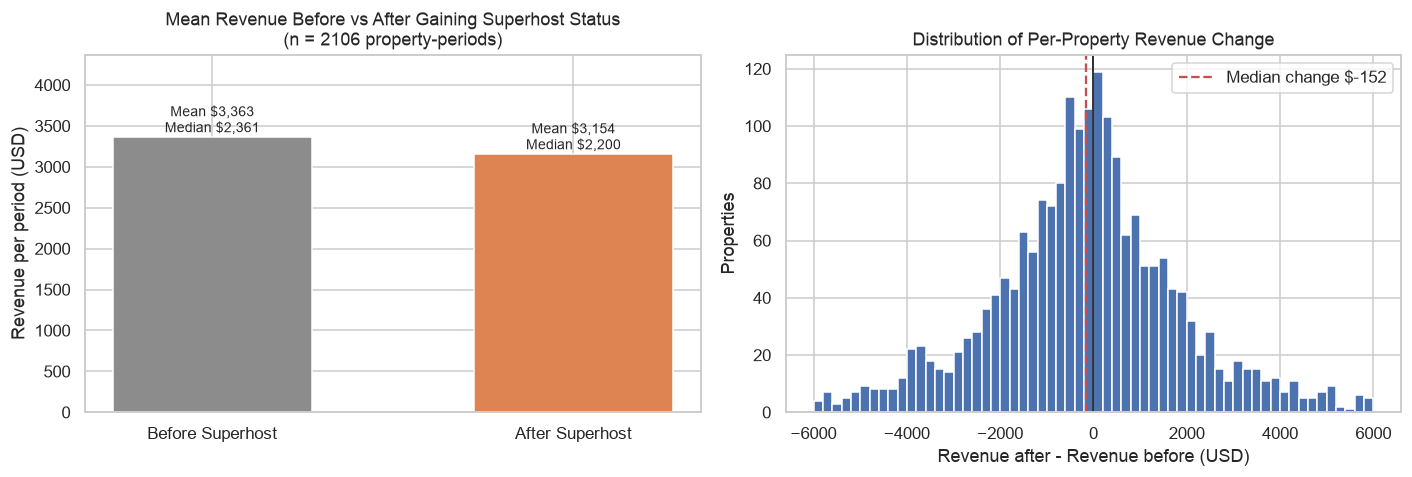

In [9]:
# The periods in which a property GAINED the badge. In these rows prev_revenue is
# the 'before' and revenue is the 'after' - same property, so it is its own control
gain = df[df['superhost_change_gain_superhost'] == 1]
print('Property-periods where Superhost status was gained: {}'.format(len(gain)))
print('Distinct properties in that set                   : {}'.format(gain['Airbnb Property ID'].nunique()))
print()

# A paired test needs both halves present, so drop rows missing either side
paired = gain.dropna(subset=['revenue', 'prev_revenue'])
print('Rows with BOTH before and after revenue recorded  : {}  ({} dropped: {} null prev_revenue,'
      ' {} null revenue)'.format(len(paired), len(gain) - len(paired),
                                 gain['prev_revenue'].isna().sum(), gain['revenue'].isna().sum()))
print('NOTE: a dropped row is usually a period with no bookings on one side, so this comparison')
print('      describes properties that were booked both before and after gaining the badge.')
print()

# Before/after summary table for the properties that gained the badge
before, after = paired['prev_revenue'], paired['revenue']
comp = pd.DataFrame({
    'Before Superhost (prev_revenue)': {'Mean': before.mean(), 'Median': before.median(),
                                        'Std dev': before.std(), 'Count': before.count()},
    'After Superhost (revenue)':       {'Mean': after.mean(), 'Median': after.median(),
                                        'Std dev': after.std(), 'Count': after.count()},
})
print('Revenue before vs after gaining Superhost status')
print(comp.round(2).to_string())
print()

# Each property's own revenue change, which is what a paired comparison needs
change = after - before
print('Per-property change in revenue (after - before)')
print('  Mean change   : ${:+,.2f}'.format(change.mean()))
print('  Median change : ${:+,.2f}'.format(change.median()))
print('  (those two null counts overlap - some rows are null on both sides)')
print('  Distinct properties behind the paired test: {}  (a few gained the badge more'.format(
    paired['Airbnb Property ID'].nunique()))
print('   than once, so they contribute more than one paired observation)')
print('  Properties whose revenue increased: {:.1%}'.format((change > 0).mean()))
print('  Properties whose revenue decreased: {:.1%}'.format((change < 0).mean()))
print('  Mean change as % of mean before   : {:+.1%}'.format(change.mean() / before.mean()))
print()

# ttest_REL (related), not ind: the two samples are the same properties measured
# twice, so the test looks at each property's own change
t, p = stats.ttest_rel(after, before)
print('Paired t-test (same property measured twice)')
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Rank-based version of the paired test - a check that does not assume normality
w, pw = stats.wilcoxon(after, before)
print('Wilcoxon signed-rank (non-parametric check)')
print('  statistic = {:,.0f}   p-value = {:.3e}'.format(w, pw))

# Left: bar chart of mean revenue before vs after gaining the badge
# Right: histogram of per-property change, to show how wide the spread around it is
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = ['Before Superhost', 'After Superhost']
means = [before.mean(), after.mean()]
medians = [before.median(), after.median()]
bars = axes[0].bar(labels, means, color=['#8C8C8C', '#DD8452'], width=0.55)
for bar, mn, mdn in zip(bars, means, medians):
    axes[0].text(bar.get_x() + bar.get_width() / 2, mn + 60,
                 'Mean ${:,.0f}\nMedian ${:,.0f}'.format(mn, mdn), ha='center', fontsize=9)
axes[0].set_title('Mean Revenue Before vs After Gaining Superhost Status\n(n = {} property-periods)'.format(len(paired)))
axes[0].set_ylabel('Revenue per period (USD)')
axes[0].set_ylim(0, max(means) * 1.30)

axes[1].hist(change, bins=60, range=(-6000, 6000), color='#4C72B0', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(change.median(), color='#C44E52', ls='--',
                label='Median change ${:+,.0f}'.format(change.median()))
axes[1].set_title('Distribution of Per-Property Revenue Change')
axes[1].set_xlabel('Revenue after - Revenue before (USD)')
axes[1].set_ylabel('Properties'); axes[1].legend()
plt.tight_layout()
plt.show()

### Q7 follow-up — before/after alone cannot answer the question

The before/after comparison says revenue went down slightly after the badge was gained.
Taken at face value that would suggest becoming a Superhost hurts revenue, which is almost
certainly wrong. The problem is that "before" and "after" are different points in time, and
Question 4 showed bookings swing hard with the season. If badges tend to be awarded going into
a weaker quarter, the drop is the calendar, not the badge.

So we add a control group: properties that did not gain the badge, measured across the
same period transitions. If gainers and non-gainers move together, the change is market-wide.
The difference between the two changes (a difference-in-differences) is the part that can
plausibly be attributed to the badge.

Gainers: n = 2106    Control (did not gain): n = 22774

Mean revenue change (this period - previous period), by evaluation period
                      Gainers  Control  Difference  Gainer rows
superhost_period_all                                           
5.0                     132.0   -301.0       433.0           60
6.0                   -1518.0   -574.0      -944.0           86
7.0                     435.0    822.0      -387.0           73
8.0                    -550.0   -401.0      -148.0          118
9.0                     262.0    -10.0       272.0          129
10.0                  -1344.0  -1136.0      -208.0          110
11.0                    510.0   1221.0      -711.0          178
12.0                  -1328.0  -1053.0      -275.0          122
13.0                    218.0    320.0      -103.0           89
14.0                   -430.0   -722.0       292.0          151
15.0                    882.0   1012.0      -131.0          169
16.0                   -364.0   -932.0

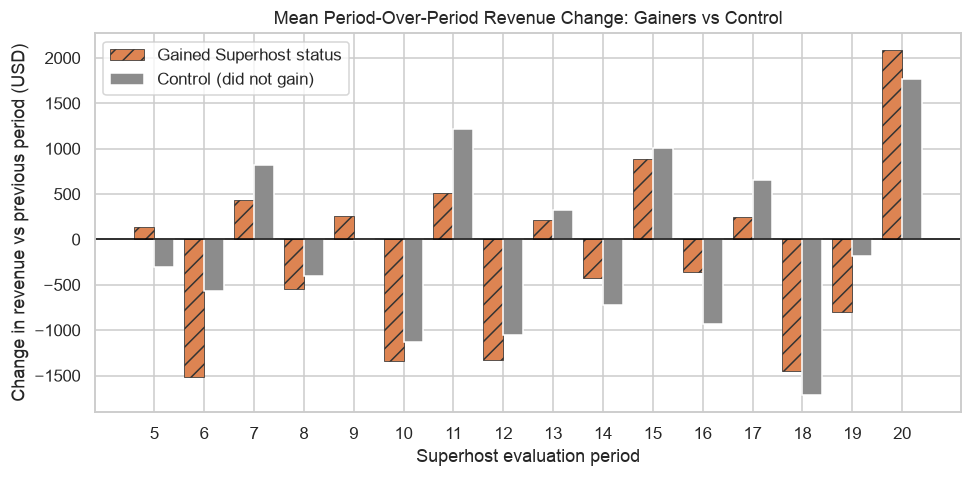

In [10]:
# Control group: properties that did NOT gain the badge, measured over the same
# period transitions. If both groups move together, the change is market-wide
control = df[df['superhost_change_gain_superhost'] == 0].dropna(subset=['revenue', 'prev_revenue'])
print('Gainers: n = {}    Control (did not gain): n = {}'.format(len(paired), len(control)))
print()

# Group a Series by another column's values: average change per evaluation period
gain_chg = (paired['revenue'] - paired['prev_revenue']).groupby(paired['superhost_period_all']).mean()
ctrl_chg = (control['revenue'] - control['prev_revenue']).groupby(control['superhost_period_all']).mean()
# Put both groups side by side, period by period
comp = pd.DataFrame({'Gainers': gain_chg, 'Control': ctrl_chg})
comp['Difference'] = comp['Gainers'] - comp['Control']
comp['Gainer rows'] = paired['superhost_period_all'].value_counts().sort_index()
print('Mean revenue change (this period - previous period), by evaluation period')
print(comp.round(0).to_string())
print()
print('-> The change swings between roughly -$1,500 and +$2,100 depending on the period.')
print('   Seasonality dwarfs anything the badge could be doing, and the control group swings')
print('   with the gainers almost period for period.')
print()

# Weight the control by the periods in which gains actually happened, so we compare
# like with like rather than letting the control's period mix do the work
# normalize=True turns counts into proportions - the share of badge-gains that
# happened in each period. These become the weights below
w = paired['superhost_period_all'].value_counts(normalize=True).sort_index()
# Weighted average: re-weight the control group so its mix of periods matches the
# gainers'. Without this we would be comparing different seasons to each other
ctrl_matched = (ctrl_chg.reindex(w.index) * w).sum()
gain_matched = (gain_chg.reindex(w.index) * w).sum()
print('Period-matched mean revenue change')
print('  Gainers                       : ${:+,.2f}'.format(gain_matched))
print('  Control, matched period mix   : ${:+,.2f}'.format(ctrl_matched))
print('  Difference-in-differences     : ${:+,.2f}'.format(gain_matched - ctrl_matched))
print()
print('Of the ${:+,.0f} raw before/after change, ${:+,.0f} is market-wide movement that the'.format(
    gain_matched, ctrl_matched))
print('control group experienced too, leaving ${:+,.0f} unexplained by seasonality.'.format(
    gain_matched - ctrl_matched))

# A point estimate on its own overstates what we know. Standard error of the weighted
# difference = gainer sampling variance + the period-weighted control variance.
_gd = (paired['revenue'] - paired['prev_revenue'])
_cd = (control['revenue'] - control['prev_revenue'])
_cvar = _cd.groupby(control['superhost_period_all']).var().reindex(w.index)
_cn = _cd.groupby(control['superhost_period_all']).size().reindex(w.index)
did = gain_matched - ctrl_matched
se = np.sqrt(_gd.var() / len(_gd) + ((w ** 2) * (_cvar / _cn)).sum())
print()
print('  Standard error                : ${:,.1f}'.format(se))
print('  95% confidence interval       : [${:+,.0f}, ${:+,.0f}]'.format(
    did - 1.96 * se, did + 1.96 * se))
print('  -> The interval CONTAINS ZERO. The difference-in-differences is not')
print('     distinguishable from zero, so the honest statement is "no measurable badge')
print('     effect in either direction" - not "the badge costs $148 per period".')

# Grouped bar chart of period-over-period revenue change, gainers vs control,
# to show the two groups rising and falling together
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp['Gainers'], width=0.4, label='Gained Superhost status', color='#DD8452',
       hatch='//', edgecolor='#333333', linewidth=0.5)   # greyscale safety
ax.bar(x + 0.2, comp['Control'], width=0.4, label='Control (did not gain)', color='#8C8C8C')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([int(p) for p in comp.index])
ax.set_title('Mean Period-Over-Period Revenue Change: Gainers vs Control')
ax.set_xlabel('Superhost evaluation period')
ax.set_ylabel('Change in revenue vs previous period (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### Findings — Question 7

Does revenue increase after gaining Superhost status? On this evidence, no — and the honest
answer is that the question as posed cannot be answered by a before/after bar chart.

Of 3,428 property-periods where the badge was gained (3,036 distinct properties), 2,106 have
revenue recorded on both sides. For those:

| | Before (`prev_revenue`) | After (`revenue`) |
|---|---|---|
| Mean | $3,362.58 | $3,154.07 |
| Median | $2,361.00 | $2,200.00 |

Revenue fell by a mean of -$208.51 and a median of -$152.50; only 45.8% of
properties improved. The paired t-test (t = -2.77, p = 0.006) and Wilcoxon (p = 2e-05) both say
the decline is larger than chance.

But the control group shows most of that decline is not about the badge. Question 4
established that bookings swing seasonally, and "before" and "after" are different quarters. When
we measure the same period-over-period change for properties that did not gain the badge, they
move almost in lockstep — both groups swing between roughly -$1,500 and +$2,100 depending on
which period transition you look at. Matching the control to the periods in which gains actually
occurred:

- Gainers: -$208 per period
- Control, same period mix: -$60
- Difference-in-differences: -$148

So of the raw $208 decline, roughly $60 is market-wide seasonal movement the control
experienced too, leaving about $148 unexplained by seasonality. That residual should not be
reported as an effect: its 95% confidence interval is **[−$307, +$10]**, which contains zero.
Once seasonality is absorbed there is no measurable badge effect in either direction.

Our conclusion: There is no evidence that gaining Superhost status raises revenue in the
period immediately after it is awarded, and the small apparent decline is mostly seasonality.
The most likely explanation for the residual is regression to the mean: the badge is awarded
following an unusually strong stretch, so the "before" figure is measured at a local peak and
almost has to fall back. This does not contradict Question 6 — Superhosts really do earn more
than non-Superhosts. It says the badge is a marker of properties that were already performing
well, not a switch that lifts revenue the moment it is granted.

Methodological note: We report the mean of the per-property change, not the difference of two
group means, because the same property is measured twice. We also dropped 1,322 rows missing one
side, so this describes properties that were booked both before and after — properties that went
from idle to booked (or the reverse) are excluded, which is exactly where a badge effect might
otherwise show up.

**What this means for the business.** This is the **prescriptive** turn in the analysis, and the
answer is a negative one worth stating plainly: gaining the badge does not raise revenue in the
period after it is awarded. Once a matched control absorbs the seasonality, the
difference-in-differences is −$148 on a $3,363 base. Management should therefore treat Superhost
status as a **selection signal** that identifies listings already performing well, not as an
intervention that lifts revenue when extended to more hosts. A policy of "award more badges to
grow revenue" would rest on a correlation this analysis does not support.


---
# Question 8 — Revenue trend across evaluation periods

> Use a line chart to illustrate the trend in revenue over multiple evaluation periods for
> Superhosts. How does Superhost status impact revenue over time?

Chart choice and why: Mean revenue by `superhost_period_all`, with both groups on one set of
axes. A Superhost line on its own cannot distinguish "Superhosts are growing" from "the whole
Dallas market is growing" — the non-Superhost line is the control.

Given the skew found in Question 6 we plot the median as well as the mean, and print the row
count per period so thin periods can be flagged.

Mean / median revenue and row count by evaluation period
                                          mean  median  count
superhost_period_all Superhost status                        
5.0                  Non-Superhost     2448.19  1618.0    593
                     Superhost         3057.90  2546.0    239
6.0                  Non-Superhost     2269.10  1346.0    605
                     Superhost         2476.95  1779.0    301
7.0                  Non-Superhost     3149.52  1950.0    597
                     Superhost         3265.21  2400.0    313
8.0                  Non-Superhost     2780.24  1870.0    718
                     Superhost         3000.27  1949.5    426
9.0                  Non-Superhost     2814.00  1945.0    811
                     Superhost         3551.95  2571.0    573
10.0                 Non-Superhost     2194.88  1395.0    913
                     Superhost         2794.35  2070.0    723
11.0                 Non-Superhost     3731.82  2059.5    952
             

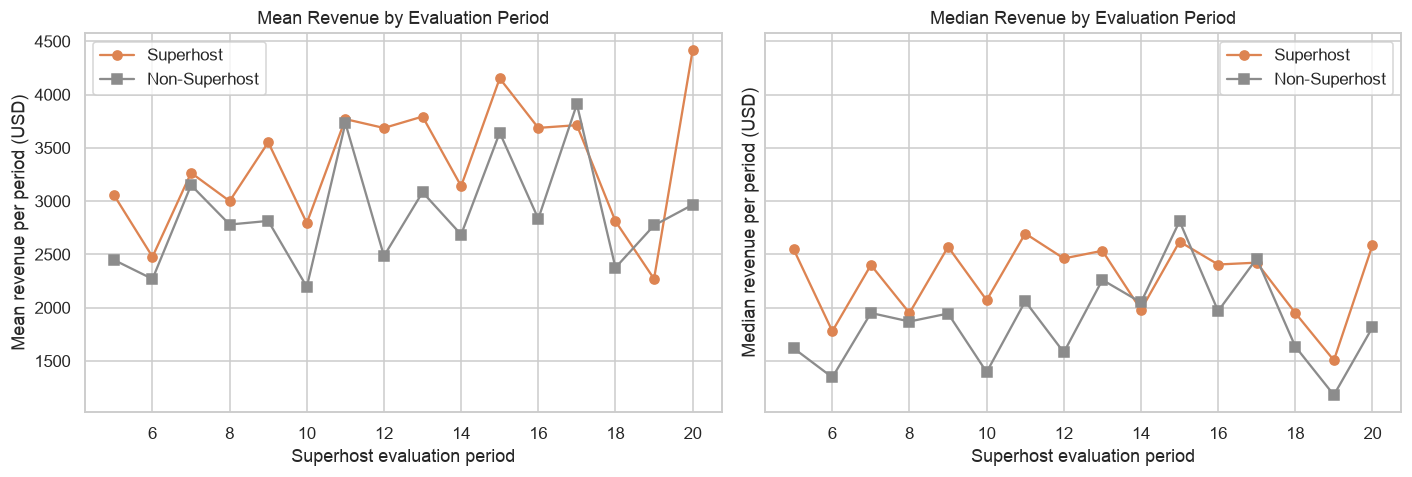

In [11]:
rev = df.dropna(subset=['revenue'])
# Grouping by two columns gives a two-level index; .agg runs several statistics at once
g = (rev.groupby(['superhost_period_all', 'Superhost status'])['revenue']
       .agg(['mean', 'median', 'count']).round(2))
print('Mean / median revenue and row count by evaluation period')
print(g.to_string())
print()

# unstack() lifts the inner index level (Superhost status) into columns, which is
# the shape matplotlib needs: one column per line on the chart
piv_mean = g['mean'].unstack()
piv_med = g['median'].unstack()
piv_n = g['count'].unstack()

# .any(axis=1) flags a period if EITHER group is thin (vs .all which needs both)
# Flag any period with thin data before we read trends off the chart
thin = piv_n[(piv_n < 100).any(axis=1)]
if len(thin):
    print('Periods with fewer than 100 rows in a group (treat with caution):')
    print(thin.astype(int).to_string())
else:
    print('No period has fewer than 100 rows in either group.')
print()

# Growth from the first period to the last, for each group
first, last = piv_mean.index.min(), piv_mean.index.max()
for lab in ['Superhost', 'Non-Superhost']:
    print('{:<14} mean revenue: period {:.0f} = ${:,.0f}  ->  period {:.0f} = ${:,.0f}  ({:+.1%})'.format(
        lab, first, piv_mean.loc[first, lab], last, piv_mean.loc[last, lab],
        piv_mean.loc[last, lab] / piv_mean.loc[first, lab] - 1))
print()
# The Superhost revenue premium in each period
gap = piv_mean['Superhost'] - piv_mean['Non-Superhost']
print('Superhost revenue premium (mean gap, USD per period)')
print(gap.round(0).to_string())
print('\nAverage premium across periods: ${:,.0f}'.format(gap.mean()))

# Line chart of revenue by period with one line per group, drawn twice:
# mean on the left, median on the right because revenue is so skewed
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, piv, name in [(axes[0], piv_mean, 'Mean'), (axes[1], piv_med, 'Median')]:
    for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
        ax.plot(piv.index, piv[lab], marker=mk, color=colr, label=lab)
    ax.set_title('{} Revenue by Evaluation Period'.format(name))
    ax.set_xlabel('Superhost evaluation period')
    ax.set_ylabel('{} revenue per period (USD)'.format(name))
    ax.legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 8

Why both groups on one chart? A Superhost line alone cannot distinguish "Superhosts are
growing" from "Dallas is growing." The non-Superhost line is the control, and we plot the median
alongside the mean because Question 6 showed how skewed revenue is.

Superhosts hold a persistent premium. Mean revenue is higher for Superhosts in 14 of the 16
evaluation periods, averaging +$465 across the 16 periods. The exceptions are periods 17
(-$196) and 19 (-$502). The premium is not stable — it ranges from $38 (period 11) to $1,449
(period 20) — which fits the seasonal swings found in Question 4 rather than any steady trend.

The premium is persistent but shows no trend. It is tempting to read growth into the two
endpoints — mean Superhost revenue runs $3,058 in period 5 against $4,415 in period 20 (+44.4%)
versus $2,448 to $2,966 (+21.1%) for non-Superhosts — but that comparison does not survive
scrutiny, for three reasons. Regressing the premium on period number gives a slope of **+$6 per
period (p = 0.82)**, indistinguishable from flat. The **median** premium moves the other way,
from $928 in period 5 to $771 in period 20. And periods are quarterly, so period 5 (Aug–Sep 2016)
and period 20 (May–Jun 2020) are *different seasons* — the exact error Questions 4 and 7 were
careful to avoid. Comparing like seasons flips the result: period 5 → 17, both Aug–Sep, gives
Superhosts +21.4% against non-Superhosts +59.7%. Period 20 is also May–June 2020, so the
endpoint sits inside the COVID shock Question 4 identified.

What the data does support: Superhosts are persistently ahead, and there is no evidence the lead
is growing. Both lines share the same saw-tooth shape, confirming that period-to-period movement
is market seasonality affecting everyone.

How to state the impact honestly. Reading this as "Superhost status increases revenue over
time" would overstate it, and Question 7 is the reason: when we isolated properties at the moment
they gained the badge and compared them against a matched control, the effect was slightly
negative. The two results are consistent if Superhost status is largely a marker of
consistently strong properties rather than a cause of revenue growth — the badge tracks
listings that were already outperforming, and those listings continue to outperform. Selection is
doing more work here than treatment.

Sample sizes support the comparison throughout: no period has fewer than 100 rows in either
group, though early periods are thinner (239 Superhost rows in period 5 vs 1,081 in period 20),
so the early points carry more sampling noise than the later ones.

**What this means for the business.** Superhosts hold a persistent premium averaging +$465 per
period, but it is stable rather than growing (slope +$6/period, p = 0.82). Read alongside
Question 7, the honest reading is **selection rather than treatment**: the badge tracks
consistently strong listings rather than creating them. The **prescriptive** implication is about
where to spend. Identifying and supporting listings *before* they qualify is more likely to move revenue
than expanding badge eligibility after the fact — the same conclusion Question 7 reached from the
opposite direction.


---
# Question 9 — Scatter plot of rating vs revenue

> Create a scatter plot to examine the relationship between rating_ave_pastYear and revenue.
> What correlation exists between ratings and revenue?

Chart choice and why: a scatter plot, because Lecture 3 maps *relationship between two
continuous variables* to a scatter. At 26,686 points a raw scatter is a block of ink, so we
draw it at `alpha=0.08` and overlay a binned-mean and binned-median line so the shape is
readable. Bins holding fewer than 30 rows are suppressed rather than plotted.

Two things have to be printed before the correlation can be interpreted. First, how
concentrated the ratings are — if there is no variation in x, there is nothing for revenue to
track. Second, a banded table of revenue **and median review count** by rating band, because
the review count is what explains what happens at the top of the scale.

A second panel splits the scatter by Superhost status on a shared y-axis: Questions 3, 6 and 8
all found the two groups behave differently, and a pooled correlation can hide subgroups moving
in opposite directions.

Total rows                            : 48,711
Dropped - null rating_ave_pastYear    : 11,629 (23.9%)
Dropped - null revenue (never booked) : 16,861 (34.6%)
Rows surviving both filters           : 26,686
Distinct properties behind those rows : 6,669 of 9,599
These are property-PERIODS, not listings: a property active in many periods contributes many points.

Distribution of rating_ave_pastYear on the 26,686 analysis rows
  min 1.00 | p5 4.35 | p25 4.68 | median 4.82 | p75 4.94 | p95 5.00 | max 5.00
  standard deviation: 0.246
  share >= 4.5: 90.1%   >= 4.8: 54.3%   exactly 5.0: 17.0%   below 4.0: 0.8%

Deciles of rating_ave_pastYear
0.1    4.500
0.2    4.625
0.3    4.718
0.4    4.771
0.5    4.818
0.6    4.858
0.7    4.914
0.8    4.965
0.9    5.000

Revenue by rating band
             rows  mean_revenue  median_revenue  median_booked_days  median_numReviews
Rating band                                                                           
<=4.0         403        1385.0           94

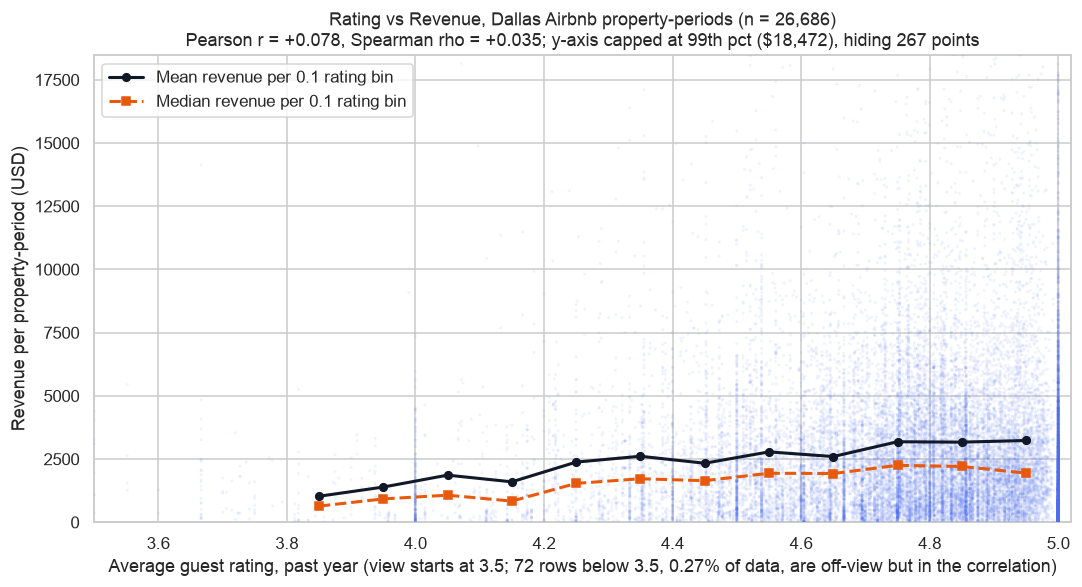

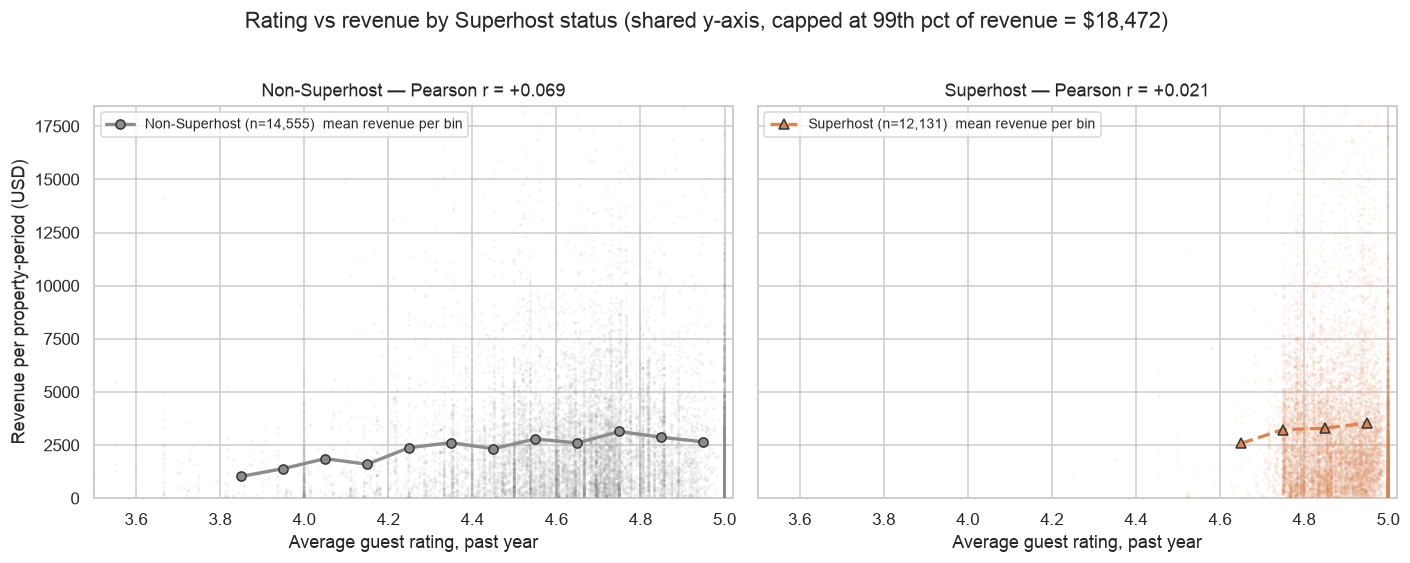

In [12]:
# Q9 asks for a relationship between two continuous variables, which Lecture 3 maps to a
# scatter plot. Both columns must be present for a point to exist, so we filter on both
# and report each filter separately - the two nulls have different meanings
q9 = df.dropna(subset=['rating_ave_pastYear', 'revenue'])
print('Total rows                            : {:,}'.format(len(df)))
print('Dropped - null rating_ave_pastYear    : {:,} ({:.1%})'.format(
    df['rating_ave_pastYear'].isna().sum(), df['rating_ave_pastYear'].isna().mean()))
print('Dropped - null revenue (never booked) : {:,} ({:.1%})'.format(
    df['revenue'].isna().sum(), df['revenue'].isna().mean()))
print('Rows surviving both filters           : {:,}'.format(len(q9)))
print('Distinct properties behind those rows : {:,} of {:,}'.format(
    q9['Airbnb Property ID'].nunique(), df['Airbnb Property ID'].nunique()))
print('These are property-PERIODS, not listings: a property active in many periods '
      'contributes many points.')
print()

# Read this block before reading the scatter. If ratings barely vary, a near-zero
# correlation is a property of the ratings scale, not evidence about quality
r = q9['rating_ave_pastYear']
print('Distribution of rating_ave_pastYear on the {:,} analysis rows'.format(len(q9)))
print('  min {:.2f} | p5 {:.2f} | p25 {:.2f} | median {:.2f} | p75 {:.2f} | p95 {:.2f} | max {:.2f}'.format(
    r.min(), r.quantile(.05), r.quantile(.25), r.median(), r.quantile(.75), r.quantile(.95), r.max()))
print('  standard deviation: {:.3f}'.format(r.std()))
print('  share >= 4.5: {:.1%}   >= 4.8: {:.1%}   exactly 5.0: {:.1%}   below 4.0: {:.1%}'.format(
    (r >= 4.5).mean(), (r >= 4.8).mean(), (r == 5.0).mean(), (r < 4.0).mean()))
print()
print('Deciles of rating_ave_pastYear')
print(r.quantile(np.arange(0.1, 1.0, 0.1)).round(3).to_string())
print()

# Required table: revenue by rating band. numReviews_pastYear is in here on purpose -
# it is what explains the shape at the top of the scale
band_edges = [-np.inf, 4.0, 4.4, 4.6, 4.8, 4.999, 5.0]
band_names = ['<=4.0', '4.0-4.4', '4.4-4.6', '4.6-4.8', '4.8-4.99', '5.0 exactly']
q9 = q9.copy()
q9['Rating band'] = pd.cut(r, bins=band_edges, labels=band_names, include_lowest=True)
band_tbl = (q9.groupby('Rating band', observed=False)
              .agg(rows=('revenue', 'size'),
                   mean_revenue=('revenue', 'mean'),
                   median_revenue=('revenue', 'median'),
                   median_booked_days=('booked_days', 'median'),
                   median_numReviews=('numReviews_pastYear', 'median'))
              .round(0))
print('Revenue by rating band')
print(band_tbl.to_string())
print()

# Correlations are computed on ALL 26,686 rows, including the sub-3.5 tail the chart
# clips and the points above the y-cap. The chart is trimmed for readability; the
# statistics are not trimmed at all
pear = stats.pearsonr(q9['rating_ave_pastYear'], q9['revenue'])
spear = stats.spearmanr(q9['rating_ave_pastYear'], q9['revenue'])
print('Correlation, rating_ave_pastYear vs revenue (n = {:,})'.format(len(q9)))
print('  Pearson  r = {:+.4f}  (p = {:.2e})   -> r-squared = {:.4f} ({:.2%} of variance)'.format(
    pear[0], pear[1], pear[0] ** 2, pear[0] ** 2))
print('  Spearman rho = {:+.4f}  (p = {:.2e})'.format(spear[0], spear[1]))
print()

print('Robustness checks')
# (a) Q6 showed revenue is heavily right-skewed; Pearson assumes a linear relation,
# so we repeat it on log revenue where the skew is pulled out
log_p = stats.pearsonr(q9['rating_ave_pastYear'], np.log(q9['revenue']))
print('  (a) Pearson on log(revenue)          r = {:+.4f} (p = {:.2e}, n = {:,})'.format(
    log_p[0], log_p[1], len(q9)))
# (b) A pooled correlation can hide subgroups moving in opposite directions
for lab in ['Non-Superhost', 'Superhost']:
    sub = q9[q9['Superhost status'] == lab]
    sp_p = stats.pearsonr(sub['rating_ave_pastYear'], sub['revenue'])
    sp_s = stats.spearmanr(sub['rating_ave_pastYear'], sub['revenue'])
    print('  (b) {:<14} Pearson r = {:+.4f} (p = {:.2e}) | Spearman rho = {:+.4f} (p = {:.2e}) | n = {:,}'.format(
        lab, sp_p[0], sp_p[1], sp_s[0], sp_s[1], len(sub)))
# (c) A rating built on 2 reviews is mostly noise; restrict to ratings with real evidence
heavy = q9[q9['numReviews_pastYear'] >= 10]
h_p = stats.pearsonr(heavy['rating_ave_pastYear'], heavy['revenue'])
h_s = stats.spearmanr(heavy['rating_ave_pastYear'], heavy['revenue'])
print('  (c) numReviews_pastYear >= 10        Pearson r = {:+.4f} (p = {:.2e}) | Spearman rho = {:+.4f} (p = {:.2e}) | n = {:,}'.format(
    h_p[0], h_p[1], h_s[0], h_s[1], len(heavy)))
print()

# The excluded third of the data. Dropping null revenue conditions the sample on having
# been booked at all, so we re-run on every rated row with never-booked periods as 0
rated = df.dropna(subset=['rating_ave_pastYear'])
z_p = stats.pearsonr(rated['rating_ave_pastYear'], rated['revenue_z'])
z_s = stats.spearmanr(rated['rating_ave_pastYear'], rated['revenue_z'])
print('Same correlation with never-booked periods counted as $0 (revenue_z, n = {:,})'.format(len(rated)))
print('  Pearson  r = {:+.4f}  (p = {:.2e})'.format(z_p[0], z_p[1]))
print('  Spearman rho = {:+.4f}  (p = {:.2e})'.format(z_s[0], z_s[1]))
print('  Mean rating, revenue present : {:.3f}  (n = {:,})'.format(
    rated.loc[rated['revenue'].notna(), 'rating_ave_pastYear'].mean(),
    rated['revenue'].notna().sum()))
print('  Mean rating, revenue null    : {:.3f}  (n = {:,})'.format(
    rated.loc[rated['revenue'].isna(), 'rating_ave_pastYear'].mean(),
    rated['revenue'].isna().sum()))
print('  -> the dropped rows rate slightly LOWER, so the booked-only frame is mildly selected.')
print('  The written answer is read from the booked-only frame (26,686 rows), because the '
      'question asks how rating relates to revenue earned; the zero-filled frame is reported '
      'so the selection is visible rather than hidden.')
print()

# --- Chart prep -------------------------------------------------------------------
# 0.1-wide rating bins. Any bin with fewer than 30 rows is suppressed rather than
# plotted, because a mean over a handful of points is noise dressed as a trend
bin_edges = np.round(np.arange(3.5, 5.01, 0.1), 2)
MIN_N = 30

def binned(frame):
    """Mean / median revenue per 0.1 rating bin, suppressing thin bins."""
    cut = pd.cut(frame['rating_ave_pastYear'], bins=bin_edges)
    agg = frame.groupby(cut, observed=False)['revenue'].agg(['size', 'mean', 'median'])
    agg['centre'] = [iv.mid for iv in agg.index]
    return agg

allb = binned(q9)
thin = allb[(allb['size'] > 0) & (allb['size'] < MIN_N)]
empty = allb[allb['size'] == 0]
print('Binned-mean line: bins suppressed for n < {} -> {}'.format(
    MIN_N, ', '.join('{} (n={})'.format(iv, int(n)) for iv, n in thin['size'].items()) or 'none'))
if len(empty):
    print('Bins with no rows at all: {}'.format(', '.join(str(iv) for iv in empty.index)))
keep = allb[allb['size'] >= MIN_N]

# The chart is clipped in both directions for readability; both clips are reported and
# neither touches the statistics above
cap = q9['revenue'].quantile(0.99)
n_above = int((q9['revenue'] > cap).sum())
n_below_x = int((q9['rating_ave_pastYear'] < 3.5).sum())
print('y-axis capped at the 99th percentile of revenue = ${:,.0f}; {:,} points ({:.1%}) '
      'sit above the cap and are not drawn.'.format(cap, n_above, n_above / len(q9)))
print('x-axis starts at 3.5; {:,} rows ({:.2%}) rate below that and are drawn off-view but '
      'are still in every correlation.'.format(n_below_x, n_below_x / len(q9)))

# --- Figure 1: the scatter --------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(q9['rating_ave_pastYear'], q9['revenue'], s=4, alpha=0.08,
           color='#4C6EF5', edgecolors='none', zorder=3)
# Two summary lines because revenue is skewed: the mean is pulled by the top tail,
# the median is what a typical listing in that band earns
ax.plot(keep['centre'], keep['mean'], color='#111827', marker='o', linestyle='-',
        linewidth=2, markersize=5, zorder=5, label='Mean revenue per 0.1 rating bin')
ax.plot(keep['centre'], keep['median'], color='#E8590C', marker='s', linestyle='--',
        linewidth=2, markersize=5, zorder=5, label='Median revenue per 0.1 rating bin')
ax.set_xlim(3.5, 5.02)
ax.set_ylim(0, cap)
ax.set_xlabel('Average guest rating, past year (view starts at 3.5; {:,} rows below 3.5, '
              '{:.2%} of data, are off-view but in the correlation)'.format(n_below_x, n_below_x / len(q9)))
ax.set_ylabel('Revenue per property-period (USD)')
ax.set_title('Rating vs Revenue, Dallas Airbnb property-periods (n = {:,})\n'
             'Pearson r = {:+.3f}, Spearman rho = {:+.3f}; y-axis capped at 99th pct '
             '(${:,.0f}), hiding {:,} points'.format(
                 len(q9), pear[0], spear[0], cap, n_above))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- Figure 2: split by Superhost status, shared y-axis ---------------------------
# Q3/Q6/Q8 all found the two groups behave differently, and a pooled correlation can
# hide subgroups pulling in opposite directions. sharey= keeps the panels comparable
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
panels = [('Non-Superhost', '#8C8C8C', 'o', '-'), ('Superhost', '#DD8452', '^', '--')]
for ax, (lab, colr, mk, ls) in zip(axes, panels):
    sub = q9[q9['Superhost status'] == lab]
    ax.scatter(sub['rating_ave_pastYear'], sub['revenue'], s=4, alpha=0.08,
               color=colr, edgecolors='none', zorder=3)
    bs = binned(sub)
    bs = bs[bs['size'] >= MIN_N]
    r_i = stats.pearsonr(sub['rating_ave_pastYear'], sub['revenue'])[0]
    ax.plot(bs['centre'], bs['mean'], color=colr, marker=mk, linestyle=ls, linewidth=2.2,
            markersize=6, markeredgecolor='#333333', zorder=5,
            label='{} (n={:,})  mean revenue per bin'.format(lab, len(sub)))
    ax.set_xlim(3.5, 5.02)
    ax.set_xlabel('Average guest rating, past year')
    ax.set_title('{} — Pearson r = {:+.3f}'.format(lab, r_i))
    ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylim(0, cap)
axes[0].set_ylabel('Revenue per property-period (USD)')
plt.suptitle('Rating vs revenue by Superhost status (shared y-axis, capped at 99th pct '
             'of revenue = ${:,.0f})'.format(cap), y=1.02)
plt.tight_layout()
plt.show()

### Findings — Question 9

Is there a correlation between higher ratings and higher revenue? Technically yes, practically
no. Pearson *r* = +0.078 across 26,686 property-periods (p = 5e-37) and Spearman rho = +0.035
(p = 1.5e-08). The p-values are tiny only because *n* is large; the effect is not.
*r*² = 0.0060, so rating explains **0.6% of the variance in revenue** — under one percent. The
robustness checks do not rescue it: log-revenue Pearson (Q6 showed how skewed revenue is)
*r* = +0.098, and restricting to ratings backed by at least 10 reviews gives *r* = +0.085,
rho = +0.070. Every variant lands in the same near-zero band.

**Range restriction is a large part of why.** The median rating is 4.82, 90.1% of rows sit at
4.5 or above, 54.3% at 4.8 or above, 17.0% are exactly 5.0, and only 0.8% fall below 4.0. The
standard deviation is 0.246 on a five-point scale. With almost all the mass packed into the top
half-point, there is very little variation in x left for revenue to track, so a near-zero
correlation is partly a property of how the Airbnb ratings system compresses — not evidence
that quality is irrelevant. The split panel makes this concrete: within Superhosts the rating
SD is 0.085 and 99.8% of rows are at 4.6 or above (the badge requires a high rating), and their
correlation collapses to *r* = +0.021 (Spearman rho = -0.011, p = 0.24, not significant). Among
non-Superhosts, where ratings actually vary (SD 0.289), *r* = +0.069. Less range, less
correlation — the pattern you expect from restriction, not from a real subgroup difference.

**The actual finding is the non-monotonicity, and Pearson cannot see it.** Reading the banded
table, mean revenue climbs steadily from $1,385 (rating <= 4.0) to $2,981 (4.6–4.8) to $3,345
(4.8–4.99) — and then *falls* to $2,916 at exactly 5.0. Median revenue falls harder, from
$2,231 to $1,596, and median booked days from 25 to 18. The review-count column explains it:
rows at exactly 5.0 have a median of **7** reviews, against 143 in the 4.6–4.8 band and 62 in
the 4.8–4.99 band. A perfect score is mostly a *thin-evidence* score — new or low-volume
listings with too few reviews for any of them to be below 5 — not a superior property. The same
mechanism runs at the other end: the <= 4.0 band also has a median of 3 reviews, so its low
revenue is partly low volume too. The usable pattern is therefore a **rise up to roughly 4.8
followed by a plateau**, and a single linear coefficient is the wrong summary for a curve that
bends.

Which frame the answer is read from. The headline numbers come from the 26,686 rows with both
a rating and a revenue figure. Re-running on all 37,082 rated rows with never-booked periods
entered as $0 (`revenue_z`) barely moves it: Pearson +0.075, Spearman +0.015. The two frames
agree, so the conclusion does not depend on the choice.

**What this means for the business.** This is **descriptive/diagnostic** analysis, and the
lever it touches is **customer intimacy** — rating is the platform's service-quality signal.
The finding is that pushing an already-4.8 listing toward 5.0 has **no measurable revenue
return**; revenue is flat-to-falling across that stretch. Incremental host effort, and any
Airbnb incentive spend, is better aimed at the ~10% of property-periods below 4.5. The
<= 4.0 band earns **$1,596 less on average** than the 4.6–4.8 band (and $1,960 less than the
4.8–4.99 band) — though the same table shows part of that gap is review volume rather than
rating, so it is an upper bound on what raising a rating alone would recover. Stated plainly: rating is a **hygiene factor, not a pricing lever**
— treating it as a **value-capture** instrument ("get to 5 stars, charge more, earn more") is a
claim this data does not support. Looking ahead to Question 11, `rating_ave_pastYear` should be
expected to sit far behind `occupancy_rate` (Pearson 0.22) and roughly level with
`numReviews_pastYear` (0.08 against 0.07) — near-zero on the linear measure. Note the ordering
depends on which coefficient is read: on rank correlation `numReviews_pastYear` (rho 0.21)
pulls well clear of rating (rho 0.03).

**Limitations.** This is correlational and cannot establish that ratings cause revenue.
(a) The causality plausibly runs backwards: more bookings generate more reviews, and more
reviews move the rating — the exactly-5.0 band, with a median of 7 reviews, is that mechanism
visible in the table. (b) Dropping the 10,396 rated-but-never-booked rows conditions the sample
on having been booked at all, which truncates the outcome variable; those rows have a slightly
*lower* mean rating (4.731 vs 4.768), so the surviving sample is mildly selected upward.
(c) Revenue is confounded by `Nightly Rate`, `Listing Type` and `Neighborhood`, none of which
are controlled here — a 4.9-rated entire home downtown and a 4.9-rated private room in an outer
ZIP are one point each on this chart. Nothing here licenses the sentence "higher ratings drive
revenue."

---
# Question 10 — Listing type composition of Superhost bookings

> What listing type dominates bookings for Superhosts? Decide on the best way to visualize the
> composition of bookings by Listing Type and explain your conclusions.

"Dominates bookings" has to be defined before it can be measured. We read it as **share of total
booked nights** — `booked_days_z`, the null-filled `booked_days` used in Q2 and Q3, so a
property-period that took no bookings enters as 0 nights instead of being dropped. A count of
rows or of listings answers a different question: how much *inventory* a type has, not how much
of the *demand* it absorbed. The cell prints all three denominators — listings, nights and
revenue — because they disagree, and the disagreement is the finding.

No rows are filtered for this question. `Listing Type` has four values and zero nulls, so all
48,711 property-periods are used and the cell prints the arithmetic proving it.

Chart choice and why: Lecture 3 maps a *composition* question to a pie or a stacked bar. We
reject the pie explicitly — there are four categories, two of them under 3.2%, a pie cannot put
Superhosts and non-Superhosts side by side, and adjacent wedges collapse into each other once
the notebook is printed to greyscale PDF. A **100% stacked horizontal bar** keeps the
part-to-whole reading, adds the group comparison a pie cannot show, and stays legible in print.
Each listing type carries both a distinct fill and a distinct hatch, and the two segments under
4% get leader labels outside the bar so they are still readable.

Panel B is the point of the figure: the same Superhost population, drawn three times under three
denominators. Reading only the booked-nights bar would mislead a manager who is actually
accountable for dollars.

MEASURE: "dominates bookings" = share of total BOOKED NIGHTS (booked_days_z, the null-filled
  booked_days used in Q2/Q3, so a property-period with no bookings enters as 0 nights rather
  than being dropped). A count of rows or of listings answers a different question - how much
  inventory a type has, not how much of the demand it absorbed - and we report those separately.

Data shape before anything is computed
  Total rows                          : 48,711
  Listing Type value counts (dropna=False):
      Entire home/apt : 36,725
      Private room    : 10,545
      Shared room     : 1,330
      Hotel room      : 111
  Null Listing Type                   : 0
  Rows with Superhost == 1            : 15,920
  Rows with Superhost == 0            : 32,791
  Rows with null booked_days          : 16,861 (34.6%) -> set to 0 nights, NOT dropped
  Rows removed by any filter in Q10   : 0  (15,920 Superhost + 32,791 non-Superhost = 48,711 = all rows)

Superhosts (15,920 property-periods, 4,189 

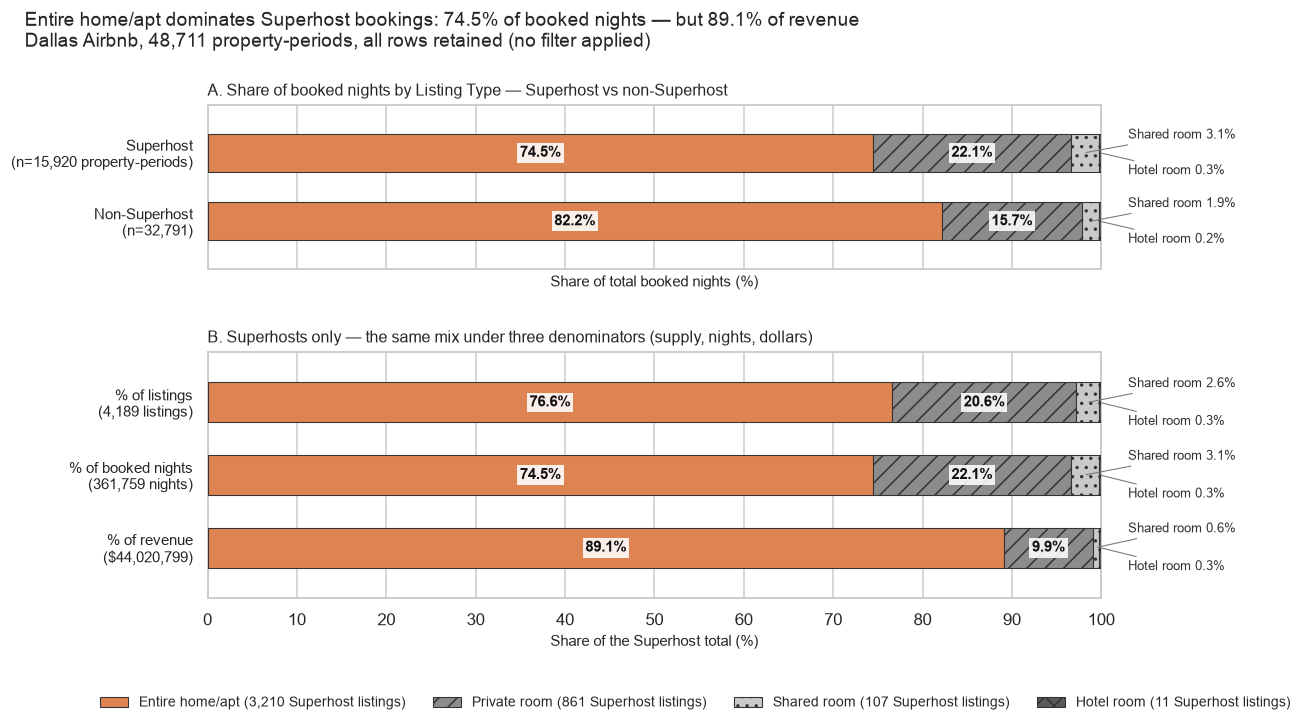

Revenue per booked night, Superhosts (total_revenue / total_booked_nights)
Listing Type
Entire home/apt    145.61
Private room        54.67
Shared room         24.95
Hotel room         123.64
  Superhost pooled average: $121.69 per booked night


In [13]:
# Q10 asks which listing type "dominates bookings", so the first job is to say what the
# measure is. Rows and listings are supply; booked nights are demand, and they disagree here
TYPE_ORDER = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
print('MEASURE: "dominates bookings" = share of total BOOKED NIGHTS (booked_days_z, the '
      'null-filled\n  booked_days used in Q2/Q3, so a property-period with no bookings '
      'enters as 0 nights rather\n  than being dropped). A count of rows or of listings '
      'answers a different question - how much\n  inventory a type has, not how much of the '
      'demand it absorbed - and we report those separately.')
print()

# --- Step 1: data shape. Nothing is filtered out in this question, so we prove it ---
print('Data shape before anything is computed')
print('  Total rows                          : {:,}'.format(len(df)))
print('  Listing Type value counts (dropna=False):')
for t, n in df['Listing Type'].value_counts(dropna=False).items():
    print('      {:<16}: {:,}'.format(str(t), int(n)))
print('  Null Listing Type                   : {:,}'.format(int(df['Listing Type'].isna().sum())))
print('  Rows with Superhost == 1            : {:,}'.format(int((df['Superhost'] == 1).sum())))
print('  Rows with Superhost == 0            : {:,}'.format(int((df['Superhost'] == 0).sum())))
print('  Rows with null booked_days          : {:,} ({:.1%}) -> set to 0 nights, NOT dropped'.format(
    int(df['booked_days'].isna().sum()), df['booked_days'].isna().mean()))
kept = int((df['Superhost'] == 1).sum()) + int((df['Superhost'] == 0).sum())
print('  Rows removed by any filter in Q10   : {:,}  ({:,} Superhost + {:,} non-Superhost = {:,} = all rows)'.format(
    len(df) - kept, int((df['Superhost'] == 1).sum()), int((df['Superhost'] == 0).sum()), kept))
print()


def composition(frame):
    """Composition of one group by Listing Type, on three different denominators.

    listings uses nunique of the property ID, not row count: this is panel data and a
    property active in 8 periods would otherwise be counted 8 times as supply.
    """
    g = frame.groupby('Listing Type', observed=False).agg(
        rows=('booked_days_z', 'size'),
        listings=('Airbnb Property ID', 'nunique'),
        total_booked_nights=('booked_days_z', 'sum'),
        mean_booked_nights_per_row=('booked_days_z', 'mean'),
        median_booked_nights=('booked_days_z', 'median'),
        total_revenue=('revenue_z', 'sum'))
    for num, name in [('listings', '% of listings'),
                      ('total_booked_nights', '% of booked nights'),
                      ('total_revenue', '% of revenue')]:
        denom = g[num].sum()
        g[name] = 100 * g[num] / denom if denom else np.nan   # guarded denominator
    return g.sort_values('total_booked_nights', ascending=False)


sh_tbl = composition(df[df['Superhost'] == 1])
ns_tbl = composition(df[df['Superhost'] == 0])

fmt = {'total_booked_nights': '{:,.0f}', 'total_revenue': '{:,.0f}',
       'mean_booked_nights_per_row': '{:.2f}', 'median_booked_nights': '{:.1f}',
       '% of listings': '{:.2f}', '% of booked nights': '{:.2f}', '% of revenue': '{:.2f}',
       'rows': '{:,}', 'listings': '{:,}'}
print('Superhosts ({:,} property-periods, {:,} distinct listings) - composition by Listing Type'.format(
    int((df['Superhost'] == 1).sum()), df.loc[df['Superhost'] == 1, 'Airbnb Property ID'].nunique()))
print(sh_tbl.to_string(formatters={k: v.format for k, v in fmt.items()}))
print()
print('Non-Superhosts ({:,} property-periods, {:,} distinct listings) - same table'.format(
    int((df['Superhost'] == 0).sum()), df.loc[df['Superhost'] == 0, 'Airbnb Property ID'].nunique()))
print(ns_tbl.to_string(formatters={k: v.format for k, v in fmt.items()}))
print()

# Side by side on the booked-nights measure only, forced into a fixed category order
# rather than trusting groupby's sort
side = pd.DataFrame({
    'Superhost %': sh_tbl['% of booked nights'],
    'Non-Superhost %': ns_tbl['% of booked nights']}).reindex(TYPE_ORDER)
side['Difference (pp)'] = side['Superhost %'] - side['Non-Superhost %']
# The listing mix is the control: if it moves too, the booked-night gap is just supply mix
side['SH listing mix %'] = sh_tbl['% of listings'].reindex(TYPE_ORDER)
side['Non-SH listing mix %'] = ns_tbl['% of listings'].reindex(TYPE_ORDER)
print('Share of booked nights, side by side (with the listing mix as a control)')
print(side.round(2).to_string())
print('  -> The listing MIX is near-identical across the two groups ({:.1f}% vs {:.1f}% entire home),'.format(
    side.loc['Entire home/apt', 'SH listing mix %'], side.loc['Entire home/apt', 'Non-SH listing mix %']))
print('     so "Superhosts favour entire homes" is not supported. The booked-night difference')
print('     comes from how intensely each type books, which is the next table.')
print()

# --- Step 2: composition vs intensity ------------------------------------------------
# A type can hold a big share because there are many of them or because each books more.
# Means only are restricted to on_market rows: an off-market row contributes 0 nights and
# so cannot move a share of totals, but it does drag a mean downward
om = df[df['on_market']]
print('Booking INTENSITY: mean booked nights per property-period, on-market rows only')
print('  On-market rows: {:,} of {:,} ({:,} off-market rows excluded from the means only;'.format(
    len(om), len(df), len(df) - len(om)))
print('  the totals above stay on all {:,} rows).'.format(len(df)))
inten = om.pivot_table(index='Listing Type', columns='Superhost status',
                       values='booked_days_z', aggfunc='mean').reindex(TYPE_ORDER)
n_rows = om.pivot_table(index='Listing Type', columns='Superhost status',
                        values='booked_days_z', aggfunc='size').reindex(TYPE_ORDER)
inten = inten[['Superhost', 'Non-Superhost']]
inten['Gap (SH - non, nights)'] = inten['Superhost'] - inten['Non-Superhost']
inten['Ratio'] = inten['Superhost'] / inten['Non-Superhost'].where(inten['Non-Superhost'] != 0)
inten['n SH'] = n_rows['Superhost']
inten['n non-SH'] = n_rows['Non-Superhost']
print(inten.round(2).to_string())
print('  -> Within Superhosts the four types book at almost the same intensity '
      '({:.1f} to {:.1f} nights),'.format(inten['Superhost'].min(), inten['Superhost'].max()))
print('     so Entire home/apt dominates because of SUPPLY ({:.1f}% of Superhost listings), '
      'not because'.format(side.loc['Entire home/apt', 'SH listing mix %']))
print('     each entire home books more than a private or shared room does.')
print()

# --- Step 3: robustness check 1, does the panel structure drive the shares? -----------
# A share of a SUM is invariant to how the sum is split across rows; a COUNT is not.
# Collapsing to one row per property proves the first half of that sentence
collapsed = (df[df['Superhost'] == 1]
             .groupby(['Airbnb Property ID', 'Listing Type'], observed=False)['booked_days_z']
             .sum().reset_index())
col_share = collapsed.groupby('Listing Type', observed=False)['booked_days_z'].sum()
col_share = 100 * col_share / col_share.sum()
chk = pd.DataFrame({'Panel rows (15,920)': sh_tbl['% of booked nights'],
                    'Collapsed to listings ({:,})'.format(len(collapsed)): col_share}).reindex(TYPE_ORDER)
chk['Difference (pp)'] = chk.iloc[:, 0] - chk.iloc[:, 1]
print('Robustness 1 - panel structure. Superhost booked-night shares, per-row vs per-listing')
print(chk.round(4).to_string())
print('  -> Largest difference: {:.10f} pp. A share of TOTALS is invariant to the panel structure. A'.format(
    chk['Difference (pp)'].abs().max()))
print('     COUNT is not: Entire home/apt is {:,} Superhost rows but only {:,} Superhost listings.'.format(
    int(sh_tbl.loc['Entire home/apt', 'rows']), int(sh_tbl.loc['Entire home/apt', 'listings'])))
print()

# --- Step 4: robustness check 2, is the headline share stable over time? -------------
per = (df[df['Superhost'] == 1]
       .pivot_table(index='superhost_period_all', columns='Listing Type',
                    values='booked_days_z', aggfunc='sum')
       .reindex(columns=TYPE_ORDER).fillna(0))
per_pct = 100 * per.div(per.sum(axis=1), axis=0)   # row sums are period totals, all > 0
print('Robustness 2 - stability over time. Superhost share of booked nights (%) by period')
print(per_pct.round(1).to_string())
eh = per_pct['Entire home/apt']
print('  -> NOT stable. Entire home/apt drifts from {:.1f}% (period {:.0f}) to {:.1f}% (period {:.0f}),'.format(
    eh.iloc[0], per_pct.index[0], eh.iloc[-1], per_pct.index[-1]))
print('     an {:.1f} pp range, while Private room falls from {:.1f}% to {:.1f}%. The headline {:.1f}%'.format(
    eh.max() - eh.min(), per_pct['Private room'].iloc[0], per_pct['Private room'].iloc[-1],
    sh_tbl.loc['Entire home/apt', '% of booked nights']))
print('     is a 16-period average of a rising trend, not a constant. Quote it as an average.')
print()

# --- Step 5: caveats that have to be printed, not left to the write-up ---------------
hotel = df[df['Listing Type'] == 'Hotel room']
hotel_sh = hotel[hotel['Superhost'] == 1]
sr = df[(df['Superhost'] == 1) & (df['Listing Type'] == 'Shared room')]
host_nights = sr.groupby('Airbnb Host ID')['booked_days_z'].sum().sort_values(ascending=False)
sr_total = host_nights.sum()
top_share = 100 * host_nights.iloc[0] / sr_total if sr_total else np.nan
top3_share = 100 * host_nights.iloc[:3].sum() / sr_total if sr_total else np.nan

print('CAVEATS')
print('(a) Hotel room is a taxonomy change, not growth. It first appears anywhere in the data at')
print('    superhost_period_all = {:.0f} and among Superhosts at period {:.0f}; periods {:.0f}-{:.0f} contain no'.format(
    hotel['superhost_period_all'].min(), hotel_sh['superhost_period_all'].min(),
    per_pct.index[0], hotel['superhost_period_all'].min() - 1))
print('    Hotel room rows at all. That is the data source recategorising listings partway through,')
print('    so its rising share is an artefact. Do not read a trend into it.')
print('(b) Shared room for Superhosts is {:,} listings across {:,} hosts. The single largest host'.format(
    sr['Airbnb Property ID'].nunique(), sr['Airbnb Host ID'].nunique()))
print('    accounts for {:.1f}% of Superhost shared-room booked nights - a plurality, not a majority -'.format(top_share))
print('    and the top three for {:.1f}%. Removing that one host cuts the shared-room share of all'.format(top3_share))
print('    Superhost booked nights from {:.2f}% to {:.2f}%. This slice describes a few operators,'.format(
    sh_tbl.loc['Shared room', '% of booked nights'],
    100 * sr.loc[sr['Airbnb Host ID'] != host_nights.index[0], 'booked_days_z'].sum()
    / df.loc[df['Superhost'] == 1, 'booked_days_z'].sum()))
print('    not a market segment.')
print('(c) No causal claim. Superhost status is awarded on host behaviour and is plausibly easier to')
print('    earn on some listing types than others, so the badge and the listing mix are jointly')
print('    determined. Everything above is an association measured across self-selected groups.')
print()

# --- Figure ---------------------------------------------------------------------------
# Composition question -> Lecture 3 says pie or stacked bar. Pie is rejected: four
# categories, two of them under 3.2%, no way to place the two host groups side by side,
# and adjacent wedges collapse into each other in the greyscale PDF. A 100% stacked
# horizontal bar keeps the part-to-whole reading AND the group comparison.
# Each type gets a distinct fill from a light-to-dark ramp AND a distinct hatch, so the
# figure survives being printed in black and white.
FILL = {'Entire home/apt': '#DD8452', 'Private room': '#8C8C8C',
        'Shared room': '#C9C9C9', 'Hotel room': '#5A5A5A'}
HATCH = {'Entire home/apt': '', 'Private room': '//',
         'Shared room': '..', 'Hotel room': 'xx'}
NARROW = 4.0     # segments thinner than this get a leader label outside the bar instead


def stacked(ax, rows, labels):
    """Draw 100%-stacked horizontal bars. rows = list of pandas Series indexed by TYPE_ORDER."""
    ypos = np.arange(len(rows))[::-1]          # first row at the top
    for y, ser in zip(ypos, rows):
        left = 0.0
        leaders = []
        for t in TYPE_ORDER:
            w = float(ser[t])
            ax.barh(y, w, left=left, height=0.55, color=FILL[t], hatch=HATCH[t],
                    edgecolor='#333333', linewidth=0.7, zorder=3)
            if w >= NARROW:
                # dark fills need light text; the orange and mid-grey take black
                txt = 'white' if t == 'Hotel room' else '#111111'
                # White backing box: the hatch lines run straight through the text otherwise
                ax.text(left + w / 2, y, '{:.1f}%'.format(w), ha='center', va='center',
                        fontsize=10, color=txt, fontweight='bold', zorder=5,
                        bbox=dict(boxstyle='square,pad=0.18', facecolor='white',
                                  edgecolor='none', alpha=0.88))
            elif w > 0:
                leaders.append((left + w / 2, t, w))
            left += w
        # Thin segments (Shared room, Hotel room) would be unreadable inside the bar, so
        # they are annotated outside it with a leader line, staggered to avoid collisions
        for k, (xc, t, w) in enumerate(leaders):
            ax.annotate('{} {:.1f}%'.format(t, w), xy=(xc, y), xytext=(103, y + (0.26 if k == 0 else -0.26)),
                        ha='left', va='center', fontsize=8.5, color='#333333',
                        arrowprops=dict(arrowstyle='-', lw=0.7, color='#777777',
                                        shrinkA=0, shrinkB=1),
                        annotation_clip=False, zorder=6)
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 10))
    ax.set_ylim(-0.7, len(rows) - 0.3)
    ax.grid(axis='y', visible=False)


fig, (axA, axB) = plt.subplots(2, 1, figsize=(12.5, 6.6), sharex=True,
                               gridspec_kw={'height_ratios': [2, 3]})

# Panel A: the two host groups, same denominator (booked nights)
stacked(axA,
        [sh_tbl['% of booked nights'].reindex(TYPE_ORDER),
         ns_tbl['% of booked nights'].reindex(TYPE_ORDER)],
        ['Superhost\n(n={:,} property-periods)'.format(int((df['Superhost'] == 1).sum())),
         'Non-Superhost\n(n={:,})'.format(int((df['Superhost'] == 0).sum()))])
axA.set_title('A. Share of booked nights by Listing Type — Superhost vs non-Superhost',
              loc='left', fontsize=10.5)
axA.set_xlabel('Share of total booked nights (%)', fontsize=9.5)

# Panel B: Superhosts only, three denominators. This panel is the finding - the mix
# looks completely different depending on whether you count listings, nights or dollars
stacked(axB,
        [sh_tbl['% of listings'].reindex(TYPE_ORDER),
         sh_tbl['% of booked nights'].reindex(TYPE_ORDER),
         sh_tbl['% of revenue'].reindex(TYPE_ORDER)],
        ['% of listings\n({:,} listings)'.format(int(sh_tbl['listings'].sum())),
         '% of booked nights\n({:,.0f} nights)'.format(sh_tbl['total_booked_nights'].sum()),
         '% of revenue\n(${:,.0f})'.format(sh_tbl['total_revenue'].sum())])
axB.set_title('B. Superhosts only — the same mix under three denominators '
              '(supply, nights, dollars)', loc='left', fontsize=10.5)
axB.set_xlabel('Share of the Superhost total (%)', fontsize=9.5)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=FILL[t], hatch=HATCH[t],
                         edgecolor='#333333', linewidth=0.7) for t in TYPE_ORDER]
labels = ['{} ({:,} Superhost listings)'.format(t, int(sh_tbl.loc[t, 'listings'])) for t in TYPE_ORDER]
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 0.005), fontsize=9)

fig.suptitle('Entire home/apt dominates Superhost bookings: {:.1f}% of booked nights — '
             'but {:.1f}% of revenue\n'
             'Dallas Airbnb, {:,} property-periods, all rows retained (no filter applied)'.format(
                 sh_tbl.loc['Entire home/apt', '% of booked nights'],
                 sh_tbl.loc['Entire home/apt', '% of revenue'], len(df)),
             x=0.012, ha='left', fontsize=12.5, y=0.985)
# Explicit margins rather than tight_layout: the leader labels are drawn outside the axes
# (annotation_clip=False) and tight_layout does not know they are there
fig.subplots_adjust(left=0.145, right=0.795, top=0.855, bottom=0.175, hspace=0.40)
plt.show()

# Revenue per booked night is what makes Panel B's gap concrete: the types are not
# selling the same product, so a night is not a comparable unit across them
rpn = (sh_tbl['total_revenue'] / sh_tbl['total_booked_nights'].where(
    sh_tbl['total_booked_nights'] != 0)).reindex(TYPE_ORDER)
print('Revenue per booked night, Superhosts (total_revenue / total_booked_nights)')
print(rpn.round(2).to_string())
print('  Superhost pooled average: ${:.2f} per booked night'.format(
    df.loc[df['Superhost'] == 1, 'revenue_z'].sum() / df.loc[df['Superhost'] == 1, 'booked_days_z'].sum()))

### Findings — Question 10

**Entire home/apt dominates: 74.5% of all Superhost booked nights** (269,461 of 361,759),
against 22.1% for Private room, 3.1% for Shared room and 0.3% for Hotel room. But on revenue
the same population splits **89.1% / 9.9% / 0.6% / 0.3%** — a 14.6 pp swing toward entire homes,
and the reason the figure draws both. Private and shared rooms together supply **25.2% of the
nights Superhosts sell but only 10.6% of the dollars**, because a Superhost entire home earns
**$145.61 per booked night** while a private room earns **$54.67** and a shared room **$24.95**.
A manager who plans capacity off the nights view and a manager who plans off the revenue view
are looking at two materially different businesses.

**The obvious explanation — "Superhosts favour entire homes" — is not supported.** The listing
mix is nearly identical across the two groups: 76.6% of Superhost listings are entire homes
against 75.1% of non-Superhost listings. Yet entire homes take 74.5% of Superhost booked nights
and 82.2% of non-Superhost booked nights, so the *composition* difference runs in the opposite
direction to the naive story: relative to non-Superhosts, Superhost bookings are **more** tilted
toward private rooms (22.1% vs 15.7%), not less. That is a difference in booking intensity
within type, not in what Superhosts choose to list.

**Composition vs intensity — the discriminating table.** On the 41,400 on-market rows, mean
booked nights per property-period for Superhosts is 24.6 (entire home), 22.3 (private room),
24.6 (shared room) and 23.2 (hotel room) — essentially flat across types. So Entire home/apt
dominates Superhost bookings **because of supply**, not because each entire home books harder
than a private room does. The Superhost-minus-non-Superhost gap, however, is *not* flat: +6.5
nights for entire homes (1.36x), +8.7 for private rooms (1.64x), +11.9 for shared rooms (1.93x),
+4.3 for hotel rooms (1.23x, n=47 and n=54, so treat it as indicative only). The Superhost
premium is proportionally **largest on the smallest types**.

**Robustness.** Collapsing the panel to one row per `Airbnb Property ID` leaves the shares
identical to 0.0000 pp — a share of totals is invariant to the panel structure, whereas a count
is not (Entire home/apt is 11,571 Superhost rows but 3,210 Superhost listings). The headline
share is **not** stable over time, though: entire homes move from 65.6% of Superhost booked
nights in period 5 to 84.2% in period 20, an 18.6 pp range, while private rooms fall from 31.4%
to 14.0%. The 74.5% is a 16-period average of a rising trend and should be quoted as an average,
not as a constant.

**Two slices that must not be over-read.** `Hotel room` first appears anywhere in the file at
`superhost_period_all` = 8 and among Superhosts only at period 12 — periods 5–7 contain no hotel
rows at all. That is the data source recategorising listings partway through the panel, not a
segment that grew, so its rising share is an artefact. `Shared room` for Superhosts is 107
listings held by 30 hosts, and the single largest host accounts for **43.0%** of Superhost
shared-room booked nights (the top three for 80.6%); dropping that one host takes the shared-room
share of all Superhost booked nights from 3.13% to 1.78%. It describes a handful of operators,
not a market segment.

**What this means for the business.** The analysis itself is **descriptive** — a composition
snapshot of where Superhost demand sits; the recommendation that follows is **prescriptive** and
should be labelled as such. The booked-nights-vs-revenue gap is a **value-capture / unit
economics** finding: room-share inventory is a quarter of the Superhost nights ledger and a tenth
of the Superhost revenue ledger, so a nights-based KPI and a revenue-based KPI rank the same
segments differently, and Airbnb's Dallas team should decide *before* setting targets which one
the Superhost programme is actually run against. Our reading is that entire homes are where the
dollars are (89.1% of revenue at 2.7x the revenue per night of a private room) and should carry
the yield and pricing work, while the room-share segment is a **volume** business that should be
managed on occupancy rather than on revenue share. The intensity table adds a **value-creation
via customer intimacy** angle worth carrying into Question 16: the Superhost booking premium is
proportionally largest exactly where the badge is rarest, 1.93x on shared rooms and 1.64x on
private rooms against 1.36x on entire homes, which is the strongest evidence in this question
that host-quality support has more headroom on room-share inventory than on entire homes — but
the shared-room number rests on 107 listings and 30 hosts and should be re-checked before
anything is built on it.

**Limitations.** This is a cross-sectional comparison of two self-selected groups and carries no
causal content. Superhost status is awarded on host behaviour (response rate, cancellations,
ratings) and is plausibly easier to earn on some listing types than others, so the badge and the
listing mix are jointly determined — nothing here separates "the badge raises bookings" from
"hosts who would book well anyway earn the badge." The 6-month booking window behind
`booked_days` also means the shares describe demand *generated* in each evaluation period rather
than occupancy, and the period-level drift shows the composition is moving, so any single share
quoted here is an average over a changing market. `Integrated Property Manager`, which would have
let us separate professional operators from individual hosts and is the obvious control for the
shared-room concentration, is 100% null in this file and could not be used.

---
# Question 11 — Correlation matrix heatmap

> Use a correlation matrix heatmap to explore the relationships between revenue,
> occupancy_rate, rating_ave_pastYear, and numReviews_pastYear. Which variables show the
> strongest correlations, and how might these impact business decisions for hosts?

**Sample choice comes before chart choice.** A 4x4 matrix can be built *pairwise* — each cell
on whatever rows happen to be complete for its own two columns — or *listwise*, on one frame
complete on all four. We use **listwise**: every cell is then computed on the same 26,686
property-periods, so the six coefficients are comparable with each other, and it is the
identical frame Question 9 used. The cell prints the proof that this is not cosmetic: pairwise
would move `revenue`~`numReviews_pastYear` from 0.214 to 0.219 and `revenue`~`occupancy_rate`
from 0.544 to 0.549, which would contradict Q9 inside the same PDF. The full null count per
column, rows dropped and rows retained are printed before anything is computed.

**Both coefficients, because they disagree.** Q6 showed revenue is heavily right-skewed and
`numReviews_pastYear` is worse (median 48, mean 245, max 3,305). Pearson measures *linear*
association and is dominated by a handful of extreme listings; Spearman measures *monotone*
association on ranks and describes the typical listing. Printing only one would hide a sign
flip and a reordering of the revenue drivers, so both matrices are drawn side by side.

Chart choice and why: Lecture 3 maps *strength of association across many variable pairs* to a
heatmap. The upper triangle **and** the diagonal are masked — the diagonal is 1.0 by
construction and the upper triangle repeats the lower — which leaves exactly the six unique
pairs on screen. Every cell is annotated with its coefficient, because a diverging colormap
maps +0.4 and -0.4 to nearly the same grey in the printed PDF: **the number, not the colour,
carries the reading.** The `revenue`~`occupancy_rate` cell is outlined in heavy black in both
panels to mark it as the one pair linked by arithmetic rather than by behaviour.

Missingness on the four KPI columns (before any filtering)
                     nulls  % of rows
revenue              16861       34.6
occupancy_rate       16861       34.6
rating_ave_pastYear  11629       23.9
numReviews_pastYear  11219       23.0

Row filtering, reported
  Total rows                          : 48,711
  Dropped - null on ANY of the four   : 22,025 (45.2%)
  Rows retained (complete cases)      : 26,686 (54.8%)
  Distinct properties behind them     : 6,669 of 9,599
  WHY LISTWISE: every cell of the matrix is then computed on the same 26,686 rows, so the six
  coefficients are directly comparable with each other - and it is the identical frame Q9 used.
  Pairwise would shift revenue~numReviews Spearman 0.214 -> 0.219 and revenue~occupancy 0.544 -> 0.549,
  contradicting Q9 inside the same PDF. Listwise keeps the document internally consistent.

Pearson correlation matrix (linear), n = 26,686


,revenue,occupancy_rate,rating_ave_pastYear,numReviews_pastYear
revenue,1.000,0.223,0.078,0.072
occupancy_rate,0.223,1.000,0.050,-0.026
rating_ave_pastYear,0.078,0.050,1.000,-0.202
numReviews_pastYear,0.072,-0.026,-0.202,1.000


Spearman correlation matrix (rank), n = 26,686


,revenue,occupancy_rate,rating_ave_pastYear,numReviews_pastYear
revenue,1.000,0.544,0.035,0.214
occupancy_rate,0.544,1.000,0.039,0.106
rating_ave_pastYear,0.035,0.039,1.000,-0.364
numReviews_pastYear,0.214,0.106,-0.364,1.000



The six unique pairs, ranked by |Spearman rho|
                                     pair  pearson_r  spearman_rho  gap (rho - r) mechanical?
                 revenue ~ occupancy_rate      0.223         0.544          0.321           Y
rating_ave_pastYear ~ numReviews_pastYear     -0.202        -0.364         -0.162           N
            revenue ~ numReviews_pastYear      0.072         0.214          0.142           N
     occupancy_rate ~ numReviews_pastYear     -0.026         0.106          0.132           N
     occupancy_rate ~ rating_ave_pastYear      0.050         0.039         -0.011           N
            revenue ~ rating_ave_pastYear      0.078         0.035         -0.043           N
  "mechanical? = Y" means the two variables are linked by arithmetic, not by behaviour:
  revenue ~= nights booked x nightly price, and occupancy_rate is nights booked scaled by
  available days. That cell is reported and then set aside; it is not a finding.



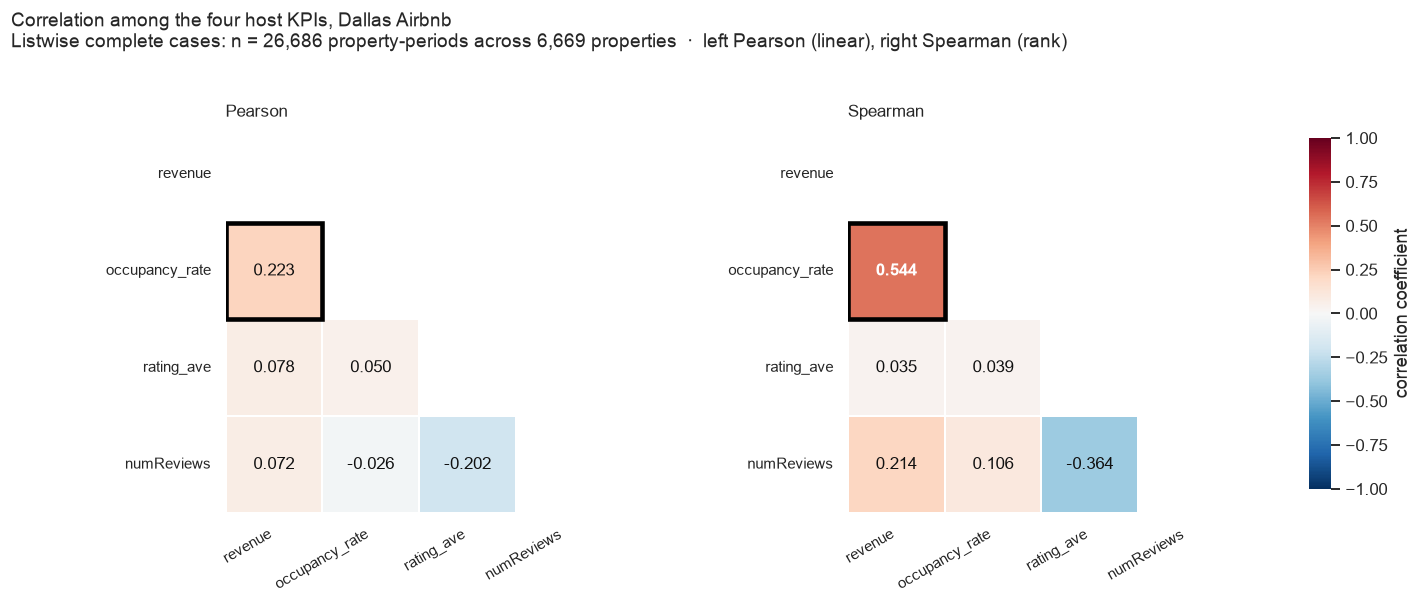

Greyscale note: a diverging colormap maps +0.4 and -0.4 to almost the same grey once this
notebook is printed, so THE PRINTED NUMBER, NOT THE COLOUR, CARRIES THE READING; the heavy
black outline marks revenue~occupancy_rate as the mechanically-linked pair in both panels.

Consistency check vs Question 9 (same 26,686-row frame)
  revenue ~ occupancy_rate       here r = +0.2229 / rho = +0.5436   Q9 reported +0.223 / +0.544   MATCH
  revenue ~ rating_ave_pastYear  here r = +0.0777 / rho = +0.0346   Q9 reported +0.078 / +0.035   MATCH
  revenue ~ numReviews_pastYear  here r = +0.0719 / rho = +0.2145   Q9 reported +0.072 / +0.215   MATCH
  -> Q9's forward reference holds; the two questions report the same numbers.
  (revenue~numReviews Spearman is 0.2145, which Q9 rounded up to 0.215 and the table above
   rounds down to 0.214. Same number, two rounding conventions.)

Superhost      n = 12,131 property-periods, 3,453 distinct properties
Non-Superhost  n = 14,555 property-periods, 5,298 dist

In [14]:
# Q11 asks for a correlation matrix over four KPIs. The first decision is not the chart,
# it is the sample: a 4x4 matrix can be built pairwise (each cell on its own complete
# rows) or listwise (one frame complete on all four). We use LISTWISE
COLS = ['revenue', 'occupancy_rate', 'rating_ave_pastYear', 'numReviews_pastYear']
q11 = df.dropna(subset=COLS)

null_tbl = pd.DataFrame({
    'nulls': df[COLS].isna().sum(),
    '% of rows': (100 * df[COLS].isna().mean()).round(1)})
print('Missingness on the four KPI columns (before any filtering)')
print(null_tbl.to_string())
print()
print('Row filtering, reported')
print('  Total rows                          : {:,}'.format(len(df)))
print('  Dropped - null on ANY of the four   : {:,} ({:.1%})'.format(
    len(df) - len(q11), 1 - len(q11) / len(df)))
print('  Rows retained (complete cases)      : {:,} ({:.1%})'.format(
    len(q11), len(q11) / len(df)))
print('  Distinct properties behind them     : {:,} of {:,}'.format(
    q11['Airbnb Property ID'].nunique(), df['Airbnb Property ID'].nunique()))
print('  WHY LISTWISE: every cell of the matrix is then computed on the same {:,} rows, so the six'.format(len(q11)))
print('  coefficients are directly comparable with each other - and it is the identical frame Q9 used.')
# Proof that the choice is not cosmetic: pairwise would move two cells and contradict Q9
pw = df[COLS].corr(method='spearman')
lw = q11[COLS].corr(method='spearman')
print('  Pairwise would shift revenue~numReviews Spearman {:.3f} -> {:.3f} and revenue~occupancy {:.3f} -> {:.3f},'.format(
    lw.loc['revenue', 'numReviews_pastYear'], pw.loc['revenue', 'numReviews_pastYear'],
    lw.loc['revenue', 'occupancy_rate'], pw.loc['revenue', 'occupancy_rate']))
print('  contradicting Q9 inside the same PDF. Listwise keeps the document internally consistent.')
print()

# --- The two matrices -----------------------------------------------------------------
# Pearson measures LINEAR association and is pulled by the extreme listings Q6 documented.
# Spearman measures MONOTONE association on ranks and reads the typical listing. Both are
# printed because the gap between them is itself a finding
pear_m = q11[COLS].corr(method='pearson').round(3)
spear_m = q11[COLS].corr(method='spearman').round(3)
print('Pearson correlation matrix (linear), n = {:,}'.format(len(q11)))
display(pear_m)
print('Spearman correlation matrix (rank), n = {:,}'.format(len(q11)))
display(spear_m)
print()

# --- Long-format ranking of the six unique pairs ---------------------------------------
# A 4x4 matrix has 16 cells but only 6 unique off-diagonal pairs; ranking them is what
# actually answers "which variables show the strongest correlations"
MECHANICAL = {('revenue', 'occupancy_rate')}
rows = []
for i, a in enumerate(COLS):
    for b in COLS[i + 1:]:
        rows.append({
            'pair': '{} ~ {}'.format(a, b),
            'pearson_r': round(q11[a].corr(q11[b], method='pearson'), 3),
            'spearman_rho': round(q11[a].corr(q11[b], method='spearman'), 3),
            'mechanical?': 'Y' if (a, b) in MECHANICAL or (b, a) in MECHANICAL else 'N'})
pairs = pd.DataFrame(rows)
pairs['gap (rho - r)'] = (pairs['spearman_rho'] - pairs['pearson_r']).round(3)
pairs = (pairs[['pair', 'pearson_r', 'spearman_rho', 'gap (rho - r)', 'mechanical?']]
         .reindex(pairs['spearman_rho'].abs().sort_values(ascending=False).index)
         .reset_index(drop=True))
print('The six unique pairs, ranked by |Spearman rho|')
print(pairs.to_string(index=False))
print('  "mechanical? = Y" means the two variables are linked by arithmetic, not by behaviour:')
print('  revenue ~= nights booked x nightly price, and occupancy_rate is nights booked scaled by')
print('  available days. That cell is reported and then set aside; it is not a finding.')
print()

# --- Figure: two heatmaps, one shared colourbar ----------------------------------------
# Lecture 3 maps "strength of association across many variable pairs" to a heatmap.
# Upper triangle AND diagonal are masked: the diagonal is 1.0 by construction and the
# upper triangle repeats the lower, so masking leaves exactly the six unique pairs.
mask = np.triu(np.ones_like(pear_m, dtype=bool))
SHORT = {'revenue': 'revenue', 'occupancy_rate': 'occupancy_rate',
         'rating_ave_pastYear': 'rating_ave', 'numReviews_pastYear': 'numReviews'}
ticks = [SHORT[c] for c in COLS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.58])
for ax, mat, name in [(axes[0], pear_m, 'Pearson'), (axes[1], spear_m, 'Spearman')]:
    sns.heatmap(mat, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
                linewidths=1.2, linecolor='white', annot=False, ax=ax,
                cbar=(name == 'Pearson'), cbar_ax=cbar_ax if name == 'Pearson' else None,
                cbar_kws={'label': 'correlation coefficient'})
    # Annotate by hand rather than with annot=True: we need the text colour switched at
    # |r| > 0.5, where the dark end of the diverging ramp swallows black text
    for r in range(len(COLS)):
        for c in range(len(COLS)):
            if mask[r, c]:
                continue
            v = mat.iloc[r, c]
            ax.text(c + 0.5, r + 0.5, '{:.3f}'.format(v), ha='center', va='center',
                    fontsize=11, color='white' if abs(v) > 0.5 else '#111111',
                    fontweight='bold' if abs(v) > 0.5 else 'normal')
    # The one mechanically-linked pair, outlined so it is not read as a behavioural finding
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor='#000000',
                               linewidth=3.0, zorder=6))
    ax.grid(False)            # the whitegrid theme otherwise rules lines across masked cells
    ax.set_xticklabels(ticks, rotation=30, ha='right', fontsize=9.5)
    ax.set_yticklabels(ticks, rotation=0, fontsize=9.5)
    ax.set_title(name, loc='left', fontsize=11)
fig.suptitle('Correlation among the four host KPIs, Dallas Airbnb\n'
             'Listwise complete cases: n = {:,} property-periods across {:,} properties  '
             '·  left Pearson (linear), right Spearman (rank)'.format(
                 len(q11), q11['Airbnb Property ID'].nunique()),
             x=0.012, ha='left', fontsize=12.5, y=0.99)
fig.subplots_adjust(left=0.13, right=0.90, top=0.80, bottom=0.16, wspace=0.30)
plt.show()
print('Greyscale note: a diverging colormap maps +0.4 and -0.4 to almost the same grey once this')
print('notebook is printed, so THE PRINTED NUMBER, NOT THE COLOUR, CARRIES THE READING; the heavy')
print('black outline marks revenue~occupancy_rate as the mechanically-linked pair in both panels.')
print()

# --- Consistency check against Question 9 ----------------------------------------------
# Q9 ran the same frame and made a forward reference to this question. If the two disagree,
# the PDF contradicts itself, so the check is printed rather than assumed
print('Consistency check vs Question 9 (same {:,}-row frame)'.format(len(q11)))
q9_reported = {'occupancy_rate': (0.223, 0.544), 'rating_ave_pastYear': (0.078, 0.035),
               'numReviews_pastYear': (0.072, 0.215)}
ok = True
for col, (p_ref, s_ref) in q9_reported.items():
    p_here = q11['revenue'].corr(q11[col], method='pearson')
    s_here = q11['revenue'].corr(q11[col], method='spearman')
    # "agrees" = the raw coefficient rounds to the value Q9 printed, +/- half a unit in
    # the 3rd decimal. 0.2145 is the boundary case: Q9 rounded it up, the table above down
    match = (abs(p_here - p_ref) < 0.0006) and (abs(s_here - s_ref) < 0.0006)
    ok = ok and match
    print('  revenue ~ {:<20} here r = {:+.4f} / rho = {:+.4f}   Q9 reported {:+.3f} / {:+.3f}   {}'.format(
        col, p_here, s_here, p_ref, s_ref, 'MATCH' if match else 'DISAGREES'))
print('  ->', 'Q9\'s forward reference holds; the two questions report the same numbers.' if ok
      else 'DISCREPANCY - do not write the prose until this is resolved.')
print('  (revenue~numReviews Spearman is 0.2145, which Q9 rounded up to 0.215 and the table above')
print('   rounds down to 0.214. Same number, two rounding conventions.)')
print()

# --- Robustness: does the pooled matrix hide a subgroup reversal? -----------------------
# Q9 found the Superhost subgroup is range-restricted (the badge requires a high rating),
# which attenuates correlations. We check whether that changes any SIGN
split = {}
for lab, flag in [('Superhost', 1), ('Non-Superhost', 0)]:
    sub = q11[q11['Superhost'] == flag]
    split[lab] = (sub, sub[COLS].corr('pearson'), sub[COLS].corr('spearman'))
    print('{:<14} n = {:,} property-periods, {:,} distinct properties'.format(
        lab, len(sub), sub['Airbnb Property ID'].nunique()))
rob = []
for lbl in pairs['pair']:                       # same order as the ranking table above
    a, b = lbl.split(' ~ ')
    sh_p, sh_s = split['Superhost'][1].loc[a, b], split['Superhost'][2].loc[a, b]
    ns_p, ns_s = split['Non-Superhost'][1].loc[a, b], split['Non-Superhost'][2].loc[a, b]
    rob.append({'pair': lbl,
                'SH r': round(sh_p, 3), 'nonSH r': round(ns_p, 3),
                'SH rho': round(sh_s, 3), 'nonSH rho': round(ns_s, 3),
                'signs agree?': 'yes' if (np.sign(round(sh_p, 3)) == np.sign(round(ns_p, 3))
                                          and np.sign(round(sh_s, 3)) == np.sign(round(ns_s, 3)))
                                else 'NO'})
rob = pd.DataFrame(rob)
print()
print('Robustness - the same six pairs computed inside each Superhost group')
print(rob.to_string(index=False))
print('  Sign agreement is computed, not assumed. Where it says NO, check the magnitude before')
print('  reading anything into it: a flip between -0.03 and +0.00 is a flip between two zeros.')
print()

# --- Block A: which lever pays ----------------------------------------------------------
# Revenue = nights x price, so the two levers a host controls are occupancy and rate.
# Logs because Q6 showed all three are right-skewed; logs also make the coefficients
# read as elasticities rather than dollar slopes
LEVERS = ['revenue', 'occupancy_rate', 'booked_days_avePrice']
pos = q11[(q11[LEVERS] > 0).all(axis=1)]
print('BLOCK A - which lever pays')
print('  Rows with all three levers strictly positive (needed for logs): {:,} of {:,} '
      '({:,} skipped)'.format(len(pos), len(q11), len(q11) - len(pos)))
logs = np.log(pos[LEVERS]).rename(columns={
    'revenue': 'log revenue', 'occupancy_rate': 'log occupancy',
    'booked_days_avePrice': 'log price'})
log_c = logs.corr('pearson').round(3)
print(log_c.to_string())
print('  log revenue ~ log occupancy : {:+.3f}'.format(log_c.iloc[0, 1]))
print('  log revenue ~ log price     : {:+.3f}'.format(log_c.iloc[0, 2]))
print('  log price   ~ log occupancy : {:+.3f}  <- near zero'.format(log_c.iloc[1, 2]))
print('  -> The two levers contribute NEARLY EQUALLY to revenue and are ALMOST UNCORRELATED with')
print('     each other in this market. A Dallas host does not have to discount to fill the calendar.')
print()

# --- Block B: where the occupancy lever runs out ----------------------------------------
# Quintiles built with labels=False -> plain integers, then relabelled, so nothing depends
# on groupby's category sort
QLAB = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)']
occ_q = pd.qcut(q11['occupancy_rate'], 5, labels=False, duplicates='drop')
rev_q = pd.qcut(q11['numReviews_pastYear'], 5, labels=False, duplicates='drop')
# One concat, not repeated inserts - repeated inserts fragment the frame and print a warning
q11x = pd.concat([q11, pd.DataFrame({
    'occ_quintile': pd.Series(occ_q, index=q11.index).map(dict(enumerate(QLAB))),
    'rev_quintile': pd.Series(rev_q, index=q11.index).map(dict(enumerate(QLAB)))},
    index=q11.index)], axis=1)

print('BLOCK B - where the occupancy lever runs out')
occ_tbl = (q11x.groupby('occ_quintile')
           .agg(n=('revenue', 'size'),
                occ_min=('occupancy_rate', 'min'), occ_max=('occupancy_rate', 'max'),
                median_revenue=('revenue', 'median'), mean_revenue=('revenue', 'mean'),
                median_nightly_price=('booked_days_avePrice', 'median'))
           .reindex(QLAB).round(2))
print(occ_tbl.to_string())
step = occ_tbl['median_revenue'].diff()
print('  Median revenue steps between quintiles: {}'.format(
    ', '.join('{:+,.0f}'.format(v) for v in step[1:])))
print('  -> Revenue rises steeply through the 4th quintile and then PLATEAUS AND DIPS in the 5th.')
print()

# Is the 5th-quintile dip just a different mix of listings? Two checks say no.
print('  Check B1 - listing-type mix by occupancy quintile (row %, guards the composition story)')
TYPES = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
mix = (pd.crosstab(q11x['occ_quintile'], q11x['Listing Type'], normalize='index') * 100
       ).reindex(QLAB).reindex(columns=TYPES).round(1)
print(mix.to_string())
print('    -> Nearly flat, and it moves the WRONG WAY for a composition explanation: Entire home/apt')
print('       rises from {:.1f}% in Q1 to {:.1f}% in Q5, so the top-occupancy quintile is MORE'.format(
    mix.loc['Q1 (lowest)', 'Entire home/apt'], mix.loc['Q5 (highest)', 'Entire home/apt']))
print('       entire-home, which would push revenue UP, not down.')
print()
print('  Check B2 - the same table within Entire home/apt only')
eh_tbl = (q11x[q11x['Listing Type'] == 'Entire home/apt'].groupby('occ_quintile')
          .agg(n=('revenue', 'size'), median_revenue=('revenue', 'median'),
               mean_revenue=('revenue', 'mean'),
               median_nightly_price=('booked_days_avePrice', 'median'))
          .reindex(QLAB).round(2))
print(eh_tbl.to_string())
print('    -> The plateau SURVIVES holding listing type constant: median revenue {:,.0f} -> {:,.0f}'.format(
    eh_tbl.loc['Q4', 'median_revenue'], eh_tbl.loc['Q5 (highest)', 'median_revenue']))
print('       from Q4 to Q5, still dipping.')
print()
print('  Check B3 - realised nightly price by occupancy quintile (the clincher)')
price_cmp = pd.DataFrame({'All listings': occ_tbl['median_nightly_price'],
                          'Entire home/apt only': eh_tbl['median_nightly_price']}).reindex(QLAB)
print(price_cmp.to_string())
print('    -> Median booked_days_avePrice FALLS as occupancy rises ({:,.2f} -> {:,.2f} pooled, '
      '{:,.2f} -> {:,.2f}'.format(price_cmp.iloc[0, 0], price_cmp.iloc[-1, 0],
                                  price_cmp.iloc[0, 1], price_cmp.iloc[-1, 1]))
print('       within entire homes). The highest-occupancy hosts are charging measurably less per')
print('       night. That is what underpricing looks like - stated as an association, not proof.')
print()

# Review COUNT vs review RATING as revenue-side metrics
print('Review volume vs review score, as revenue metrics')
rq_tbl = (q11x.groupby('rev_quintile')
          .agg(n=('revenue', 'size'), median_numReviews=('numReviews_pastYear', 'median'),
               median_rating=('rating_ave_pastYear', 'median'),
               median_revenue=('revenue', 'median'))
          .reindex(QLAB).round(3))
print(rq_tbl.to_string())
print('  -> Median rating falls MONOTONICALLY as review volume rises ({:.2f} at a median of {:,.0f}'.format(
    rq_tbl.loc['Q1 (lowest)', 'median_rating'], rq_tbl.loc['Q1 (lowest)', 'median_numReviews']))
print('     reviews down to {:.2f} at {:,.0f}), while median revenue RISES from ${:,.0f} to ${:,.0f}.'.format(
    rq_tbl.loc['Q5 (highest)', 'median_rating'], rq_tbl.loc['Q5 (highest)', 'median_numReviews'],
    rq_tbl.loc['Q1 (lowest)', 'median_revenue'], rq_tbl.loc['Q5 (highest)', 'median_revenue']))
print('     A perfect score is a THIN-EVIDENCE score, not a quality signal.')
print()

# Why Spearman is the coefficient to read here: the skew that breaks Pearson
print('Why Spearman is the coefficient to interpret (the skew Pearson cannot survive)')
skew_tbl = pd.DataFrame({
    'median': q11[COLS].median(), 'mean': q11[COLS].mean(),
    'max': q11[COLS].max(), 'skewness': q11[COLS].skew()}).round(2)
print(skew_tbl.to_string())
print('  numReviews_pastYear: median {:,.0f}, mean {:,.0f}, max {:,.0f}. Pearson is dominated by a'.format(
    q11['numReviews_pastYear'].median(), q11['numReviews_pastYear'].mean(),
    q11['numReviews_pastYear'].max()))
print('  handful of extreme listings; Spearman reads the typical one. Q6 measured the same skew on')
print('  revenue (skewness 4.83 non-Superhost / 7.24 Superhost).')
print('  Ordering of the three revenue drivers is NOT the same under the two coefficients:')
print('    Spearman: occupancy {:+.3f} >> reviews {:+.3f} >> rating {:+.3f}'.format(
    spear_m.loc['revenue', 'occupancy_rate'], spear_m.loc['revenue', 'numReviews_pastYear'],
    spear_m.loc['revenue', 'rating_ave_pastYear']))
print('    Pearson : occupancy {:+.3f} >> rating {:+.3f} ~ reviews {:+.3f}'.format(
    pear_m.loc['revenue', 'occupancy_rate'], pear_m.loc['revenue', 'rating_ave_pastYear'],
    pear_m.loc['revenue', 'numReviews_pastYear']))

### Findings — Question 11

**The strongest cell in the matrix is not a finding.** `revenue`~`occupancy_rate` is the
largest coefficient in both panels (Spearman rho = +0.544, Pearson *r* = +0.223) and it is
**arithmetic**: revenue is nights booked x nightly price, and `occupancy_rate` is nights booked
scaled by available days, so the two share a term by construction. It is reported, outlined in
the figure, and then set aside. It cannot be the headline.

**The strongest genuine relationship is negative: `rating_ave_pastYear`~`numReviews_pastYear`
at rho = -0.364** (*r* = -0.202). More reviews go with a *lower* average score, and Q9 already
showed the mechanism. Splitting the 26,686 rows into review-count quintiles, median rating falls
monotonically at every step: **5.000** at a median of 5 reviews, **4.875** at 20, **4.854** at
48, **4.806** at 143, **4.745** at 623. A perfect score is a **thin-evidence** score — too few
reviews for any of them to be below 5 — not a quality signal. This is the single most useful
cell in the matrix for a host, because it says the two review-side metrics point in opposite
directions and cannot both be maximised.

**The Pearson/Spearman gap is large and directional, and Spearman is the coefficient to read
here.** `revenue`~`numReviews_pastYear` moves from *r* = +0.072 to rho = +0.214, and
`occupancy_rate`~`numReviews_pastYear` **flips sign**, from *r* = -0.026 to rho = +0.106. The
cause is the skew Q6 established (revenue skewness 4.83 non-Superhost / 7.24 Superhost; 7.15
pooled on this frame) plus the review-count skew (median 48, mean 245, max 3,305): Pearson is
pulled by a few extreme listings, Spearman reads the typical one. The consequence is that the
ranking of the three revenue drivers **is not the same under the two coefficients** — on
Spearman it is occupancy (+0.544) >> reviews (+0.214) >> rating (+0.035), but on Pearson it is
occupancy (+0.223) >> rating (+0.078) ~ reviews (+0.072). Anyone quoting "the correlation" from
one matrix would rank review volume and review score differently depending on which they picked.

**Consistency with Question 9.** All three `revenue` correlations reproduce Q9 exactly on the
same frame: occupancy +0.2229 / +0.5436, rating +0.0777 / +0.0346, reviews +0.0719 / +0.2145.
Q9's forward reference holds. (Q9 rounded the review figure up to 0.215 and the ranking table
here rounds it down to 0.214; it is the same number.)

**Robustness by Superhost status.** Recomputed inside each group — Superhost n = 12,131 across
3,453 properties, non-Superhost n = 14,555 across 5,298 — the relationships are **attenuated
inside the Superhost group** exactly as the range restriction Q9 documented predicts:
`revenue`~`occupancy_rate` 0.187 vs 0.274 Pearson, `revenue`~`numReviews_pastYear` 0.047 vs
0.132 — while `rating_ave_pastYear`~`numReviews_pastYear` **strengthens** to -0.310 vs -0.140.
Three of the six pairs do not preserve sign across the split, but all three are the near-zero
cells: `occupancy_rate`~`numReviews_pastYear` (+0.004 vs -0.032 Pearson),
`occupancy_rate`~`rating_ave_pastYear` (-0.022 vs +0.059) and `revenue`~`rating_ave_pastYear`
(-0.011 vs +0.030 Spearman). A flip between -0.03 and +0.00 is a flip between two zeros; every
pair large enough to act on keeps its sign, so the pooled matrix is not hiding a reversal.

**Which lever pays (Block A).** On the same 26,686 rows, in logs, `revenue`~`occupancy_rate`
is +0.612 and `revenue`~`booked_days_avePrice` is +0.542 — the two levers a host controls
contribute **nearly equally** — and they are **almost uncorrelated with each other**
(-0.056). In this market a host does not have to discount to fill the calendar; price and
occupancy are close to independent decisions.

**Where the occupancy lever runs out (Block B).** Median revenue by occupancy quintile is
$456 / $1,495 / $2,464 / $3,290 / $3,180 — steps of +$1,039, +$968, +$826, then **-$110**.
Revenue rises steeply through the 4th quintile and then plateaus and dips in the 5th. Two checks
say this is not a composition artefact. The listing-type mix across quintiles is nearly flat and
moves the *wrong* way for that story — Entire home/apt rises from 68.0% in Q1 to 79.2% in Q5, so
the top-occupancy quintile is *more* entire-home, which would push revenue up rather than down —
and within Entire home/apt alone (n ~ 4,000 per quintile) the plateau survives: $652 / $1,827 /
$2,920 / **$3,816 / $3,731**. The clincher is realised price: median `booked_days_avePrice`
*falls* as occupancy rises, $95.00 / $97.14 / $94.74 / $90.09 / $90.09 pooled and $120.00 /
$113.83 / $108.39 / $101.37 / $102.68 within entire homes. The highest-occupancy hosts are
charging measurably less per night, which is what underpricing looks like — stated as an
association in cross-section, not as proof of causation.

**What a host should actually do.** First, chase occupancy only up to the plateau: below roughly
30% occupancy (the top of the 4th quintile) every extra point of occupancy is worth real money,
but above it median revenue stops rising, and the price table says those hosts are already
selling nights $30 cheaper than the least-occupied entire homes — the next dollar comes from
raising the rate, not from filling more nights. Second, do **not** buy review volume expecting a
rating lift: the two run in opposite directions (rho = -0.364), and a 5.00 average on 5 reviews
is not evidence of quality. Third, treat review *count*, not average rating, as the review-side
metric worth growing — it tracks revenue (rho = +0.214; median revenue $1,341 in the lowest
review quintile against $2,773 in the highest) while average rating essentially does not
(rho = +0.035) — so accepting the small rating cost that comes with volume is the right trade.
Fourth, since price and occupancy are near-independent here (-0.056), test a rate increase
before assuming it will cost bookings.

**Limitations.** Nothing here is causal. These are cross-sectional associations measured on
panel data, and the largest cell in the matrix, `revenue`~`occupancy_rate`, is *definitionally*
linked rather than behaviourally. The panel structure also inflates statistical significance:
6,669 properties supply 26,686 rows, so the observations are not independent and any p-value
would be badly overstated — consistent with Q5 and Q9, we report effect sizes only and print no
p-values. And the retained frame is selected: the 22,025 dropped rows are largely the
listed-but-unbooked and off-market periods identified in Q2/Q3, so this matrix describes
listings that **actually booked and were reviewed**, not the Dallas market as a whole. The
occupancy-plateau reading in particular is an association across self-selected hosts — hosts who
run at high occupancy may differ from the rest in ways (location, property quality, professional
management) this data does not control for.

**What this means for the business.** This is **descriptive / diagnostic** analysis: a
correlation matrix maps the strength of association between candidate drivers and is the
feature-selection step that comes *before* any predictive model — it tells us `occupancy_rate`
and `numReviews_pastYear` are worth carrying into a revenue model and `rating_ave_pastYear` is
not. Two levers follow. The occupancy plateau is a **value-capture (pricing / unit economics)**
finding: past roughly 30% occupancy the marginal night stops adding revenue and the realised
nightly rate is falling, so the yield conversation for high-occupancy hosts should be about
rate, not volume — and because occupancy and price are near-uncorrelated in this market, that
rate increase is not obviously bought with empty nights. The review finding is **value creation
via customer intimacy**: review volume is the customer-feedback asset that moves with revenue,
average rating is a hygiene factor that does not, so host coaching and platform prompts should
be aimed at getting *more* guests to review rather than at protecting a 5.00 score that mostly
signals a thin book of evidence.